In [1]:
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import random
import tensorflow as tf
import numpy as np
import timeit
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics
import scipy.io as sio
import csv
import os
import math 
import random as rand
from numpy import genfromtxt
from numpy import sum,isrealobj,sqrt
from numpy.random import standard_normal
from keras.models import load_model

#import torch
#from torch import nn

import warnings
from scipy.spatial import distance



import sys
sys.path.append("..") # Adds higher directory to python modules path.

from Modules.Tools import MapTool
from Modules.Tools import BoxPlot
from Modules.Tools import peakCorrelation as pC

In [2]:
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
          'font.weight': "bold",
         'lines.linewidth': 5}
plt.rcParams.update(params)

# Notebook Parameters
- this is simply for obtaining the graphs with manual mapping. Pad is closely relate to the sampling rate for the EM signal

In [3]:
pad = 8

# Load Dataset

In [4]:
load_Folder = "./Datasets/FP_GANs_LargeScale_2/k-Fold/TrainingDatasets/"

In [5]:
alpha = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/Alpha/Alpha_major_peaks.npy", allow_pickle=True)

In [6]:
'''
Method extracts the sequence of code that would be from the middle point before the first instruction and after the last
instruction
'''
def extract(Signal, midpoint):
    instEM = np.copy(Signal)
    
    done = 0
    while done == 0:
        if instEM[0] < midpoint:
            instEM = instEM[1:]
        else:
            done = 1
    
    ## remove from the end of signal
    done = 0
    while done == 0:
        if instEM[instEM.shape[0]-1] > midpoint:
            instEM = instEM[:instEM.shape[0]-2]
        else:
            done = 1
    
    return instEM

In [7]:
'''
This method will take EM signals' major peaks and stitch them together in the order given returning 1 EM signal of major peaks only.

dataset: a 2D numpy array of the generated EM signals to be stitched together.
amount: amount of instruction contained in the EM signal
pad: The padding amount that referse to the amount of time index it takes to complete half a peak to peak interval
midpoint: the common mid or avg point between the high and low peaks. (if no preprocessing on signals it will be 0,
if normalized then it will be 0.5)
'''
def EMstitching_Peaks(dataset, amount, pad, midpoint):
    # list of EMs to stitch together.
    first = True
    # cycle through the dataset
    for n in range(dataset.shape[0]):
        signal_Major_Peaks = dataset[n]["Seq"]
        code = dataset[n]["Code"]
        
        # obtain the EM of the important instruction from generated EM sequence of instructions
        ## Not necessary as we switched to generative model only producing the last instructions EM.
        EM = signal_Major_Peaks
        
        # stitch together into one EM
        if first == True:
            EMFinal = np.copy(EM)
            first = False
        else:
            EMFinal = np.concatenate((EMFinal, EM))
    
    EMFinal = np.array(EMFinal)
    return EMFinal

In [8]:
load_Folder = "./Results/"
Gen_Model = load_model(load_Folder + "Generate_Full-centroid/Model/Model_Epoch-220.h5")
Gen_alpha_90 = load_model(load_Folder + "Generate_90_Alpha-centroid/Model/BestModel.h5")

In [9]:
def generateFakeSignals(codes, latent_dim, Gen, num):
    seqs = []
    for code in codes:
        seq = []
        code = np.repeat(np.reshape(code, (1,-1)),num, axis =0)
        random_latent_vectors = tf.random.normal(shape=(num, latent_dim))
        random_vector_codes = tf.concat([random_latent_vectors, code], axis=1)
        seqs.append(Gen(random_vector_codes))
    
    seqs = np.array(seqs)
        
    first = True
    gen_Signals = seqs[0]
    for s in range(len(codes)-1):
        gen_Signals = np.concatenate((gen_Signals, seqs[s+1]), axis=1)
    
    return np.array(gen_Signals)

In [10]:
load_Folder = "./Datasets/FP_GANs_LargeScale_2/k-Fold/TrainingDatasets/"

alpha_Code = np.load(load_Folder + "Alpha_Base_code.npy", allow_pickle = True).tolist()

In [ ]:
alpha_Gen_Signals = generateFakeSignals(alpha_Code, 1, Gen_Model, 3000)

In [ ]:
load_Folder = "./Datasets/Numpy/Generated/"
np.save(load_Folder + "alpha_Gen_Signals.npy", alpha_Gen_Signals)

In [13]:
alpha_90_Gen_Signals = generateFakeSignals(alpha_Code, 1, Gen_alpha_90, 1500)

In [ ]:
load_Folder = "./Datasets/Numpy/Generated/"
np.save(load_Folder + "alpha_90_Gen_Signals.npy", alpha_90_Gen_Signals)

In [11]:
load_Folder = "./Datasets/Numpy/Generated/"
alpha_Gen_Signals = np.load(load_Folder + "alpha_Gen_Signals.npy", allow_pickle = True)
alpha_90_Gen_Signals = np.load(load_Folder + "alpha_90_Gen_Signals.npy", allow_pickle = True)

In [22]:
Save_Gen = "./Results/One_Inst_Stitching/"
alpha_EM_Stitch = np.load(Save_Gen + "EM_Stitch_Alpha.npy")

In [12]:
alpha_sub = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/Alpha_sub/Alpha_sub_major_peaks.npy", allow_pickle=True)

In [18]:
alpha_sub.shape

(1280, 13)

In [13]:
def cutToLength(dataset, length):
    new_Dataset = np.zeros((dataset.shape[0],length))
    
    for i in range(dataset.shape[0]):
        temp = dataset[i]
        new_Dataset[i] = temp[:length]
    
    new_Dataset = np.array(new_Dataset)
    return new_Dataset

In [14]:
alpha_sub = cutToLength(alpha_sub, 12)
print(alpha.shape)
print(alpha_sub.shape)

(3000, 12)
(1280, 12)


In [25]:
alpha.shape

(3000, 12)

# Similarity Plot

# Alpha

In [15]:
Real_Vs_Real_Alpha = pC.averageSimilarityExpReturn(alpha[0:1500], alpha[1500:3000], "Real_1", "Real_2", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [16]:
Real_Vs_Gen_Alpha = pC.averageSimilarityExpReturn(alpha[0:1500], alpha_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [17]:
Real_Vs_Gen_90_Alpha = pC.averageSimilarityExpReturn(alpha[0:1500], alpha_90_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [23]:
Real_Vs_Stitch_Alpha = pC.averageSimilarityExpReturn(alpha[0:1500], alpha_EM_Stitch[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [29]:
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
         'lines.linewidth': 5}
plt.rcParams.update(params)

(1500,)


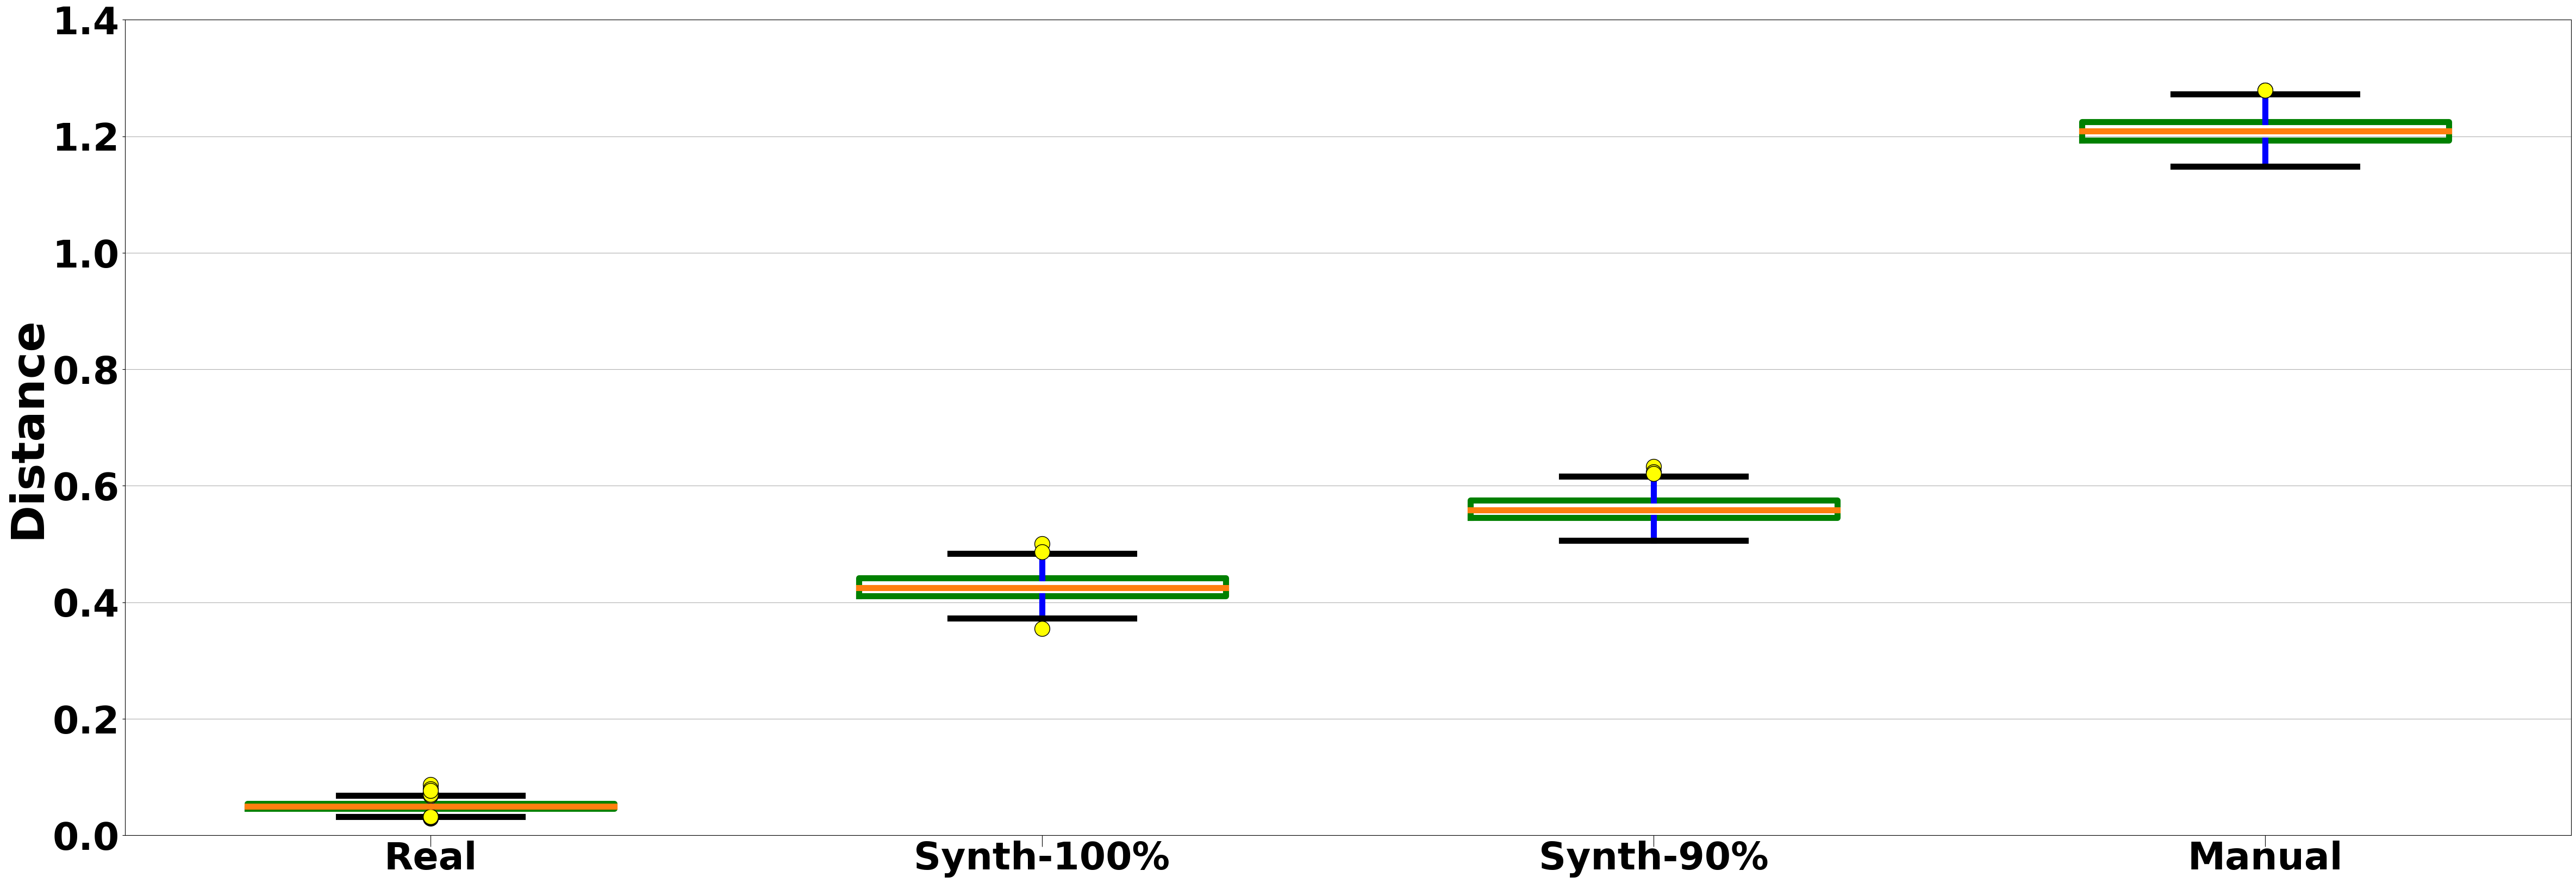

In [46]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Real_Vs_Real_Alpha, "Real"],
                      [Real_Vs_Gen_Alpha, "Synth-100%"],
                       [Real_Vs_Gen_90_Alpha, "Synth-90%"],
                      [Real_Vs_Stitch_Alpha, "Manual"],),
                      dtype = object)

folder="./Graphs/6_1 Analyzing Similarity/Similarity_BP_Alpha.png"
BoxPlot.boxPlotDataSeparate(dictionary, "", "Distance", "", 
                 0.0, 1.4, pad, figsize=(45,15), folder=folder)

In [ ]:
Gen_Vs_Gen_Alpha = pC.averageSimilarityExpReturn(alpha_Gen_Signals[0:1500], alpha_Gen_Signals[1500:3000], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [ ]:
Gen_Vs_Real_Alpha = pC.averageSimilarityExpReturn(alpha_Gen_Signals[0:1500], alpha[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [ ]:
Gen_Vs_sub_Alpha = pC.averageSimilarityExpReturn(alpha_Gen_Signals[0:1500], alpha_sub[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [ ]:
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
         'lines.linewidth': 5}
plt.rcParams.update(params)

(1500,)


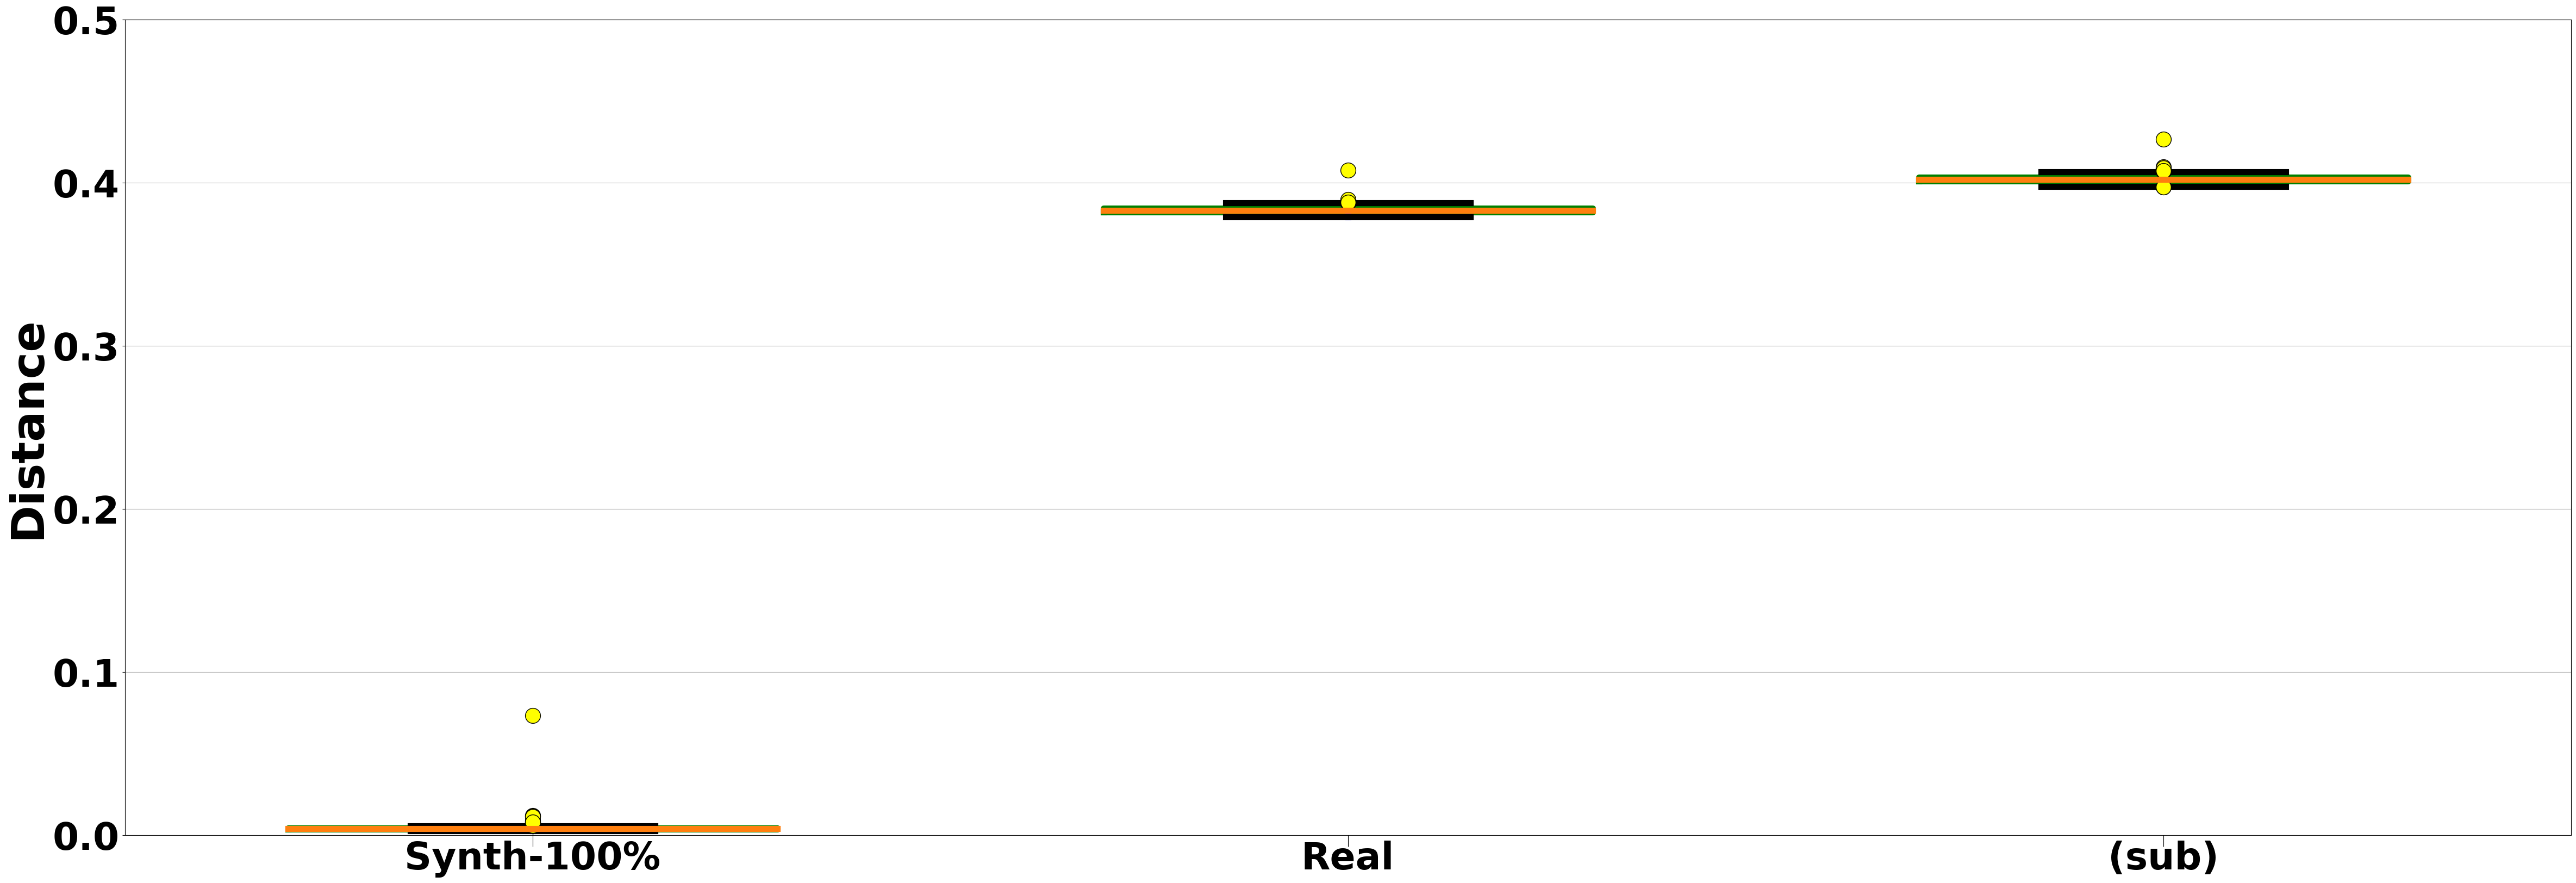

In [35]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Gen_Vs_Gen_Alpha, "Synth-100%"],
                      [Gen_Vs_Real_Alpha, "Real"],
                       [Gen_Vs_sub_Alpha, "(sub)"],),
                      dtype = object)

folder="./Graphs/6_1 Analyzing Similarity/Similarity_BP_Gen-Alpha.png"
BoxPlot.boxPlotDataSeparate(dictionary, "", "Distance", "", 
                 0.0, 0.5, pad, figsize=(45,15), folder=folder)

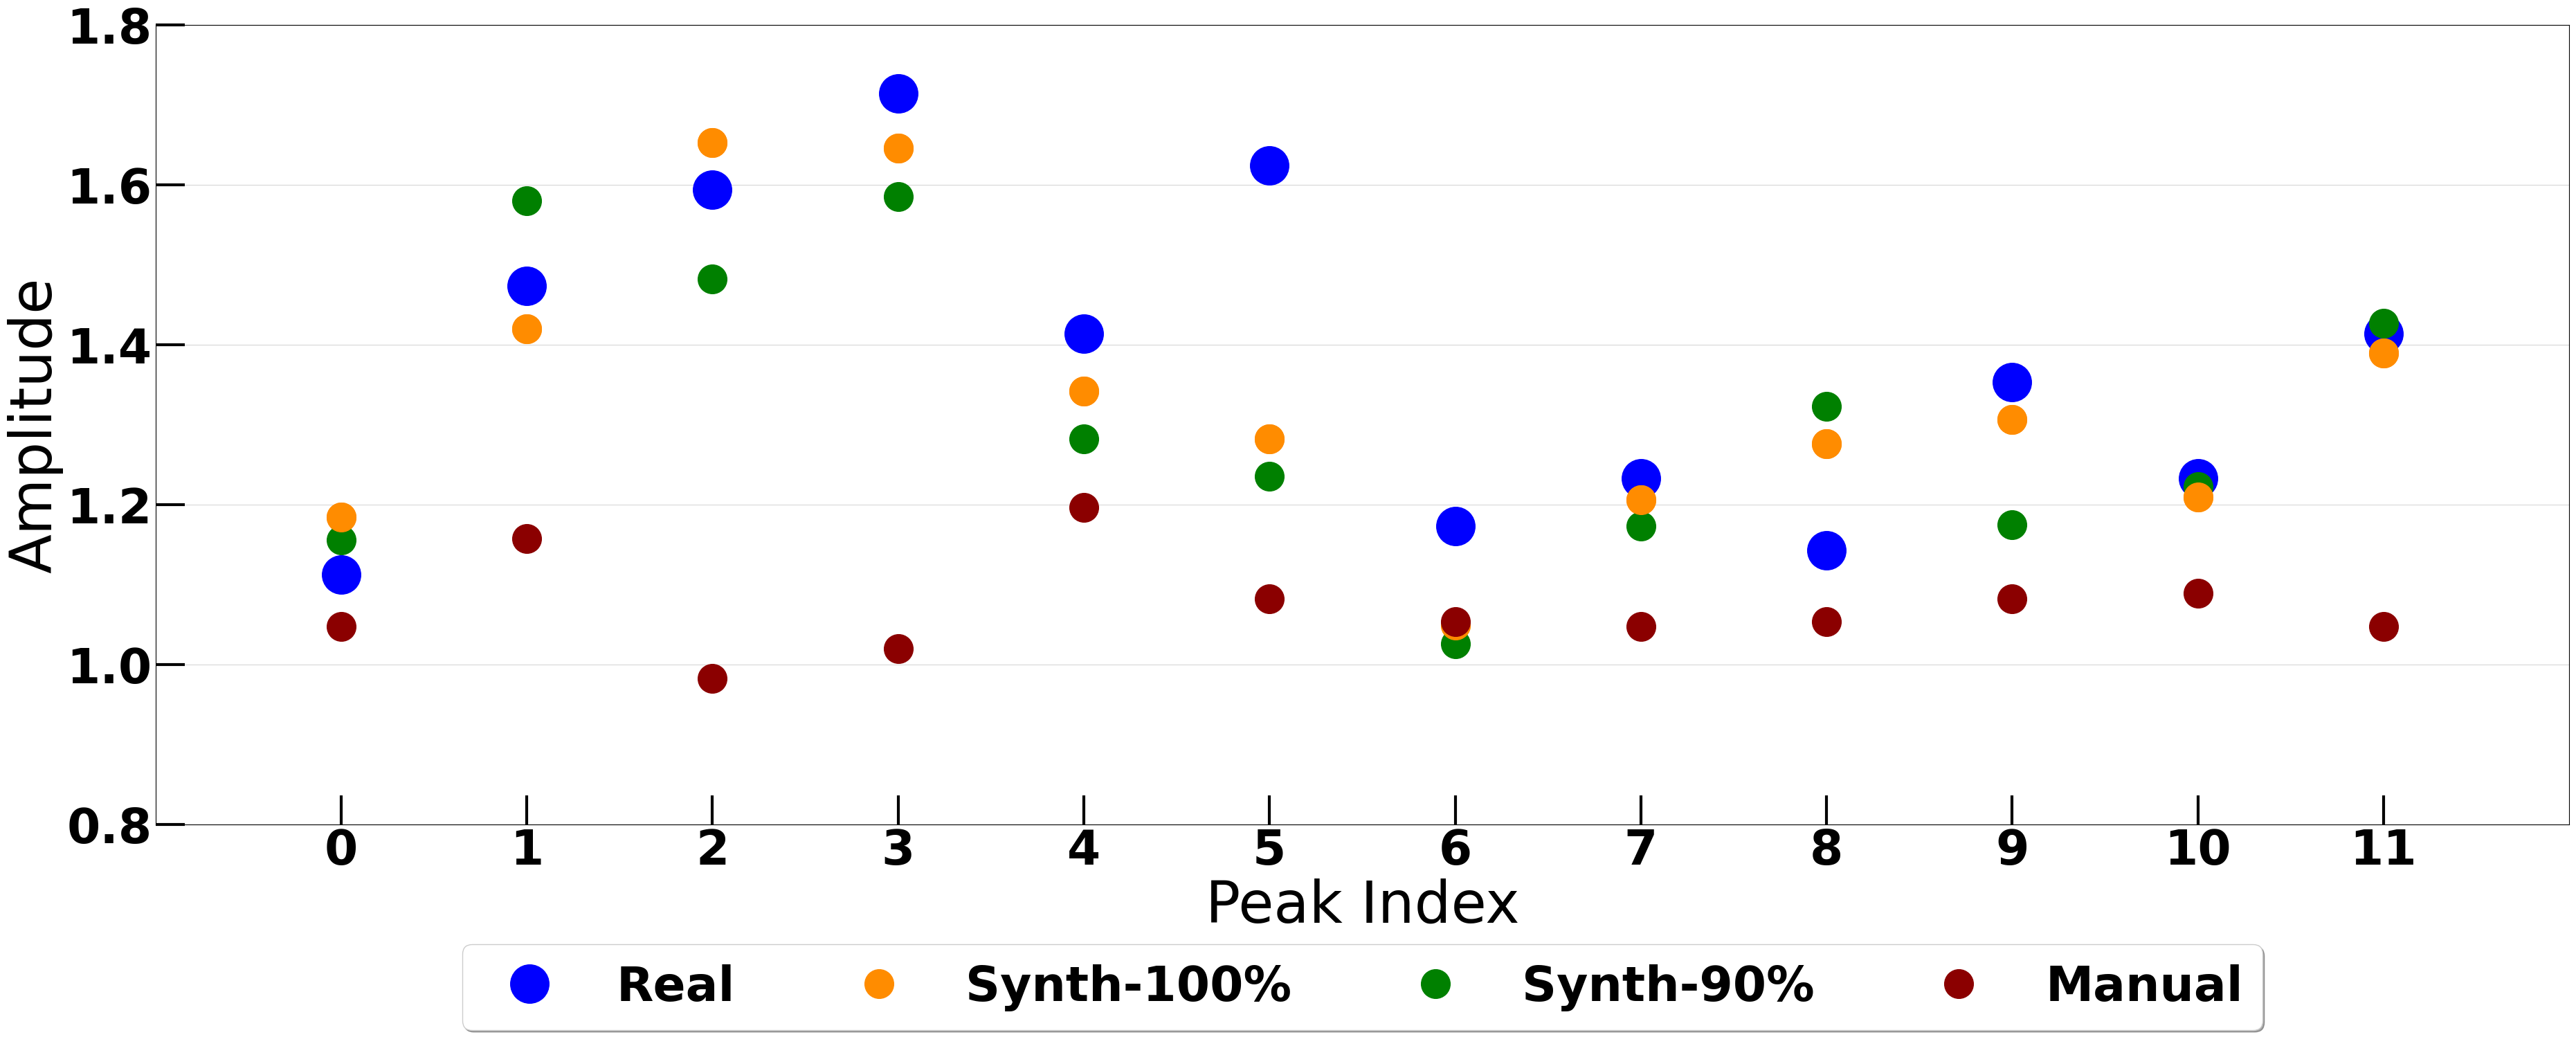

In [50]:
real_signal = alpha[0]
synth_100_signal = alpha_Gen_Signals[0]
synth_90_signal = alpha_90_Gen_Signals[0]
manual_signal = alpha_EM_Stitch[0]

time_Signal = np.arange(real_signal.shape[0])
plt.plot(time_Signal, real_signal, 'o', color='blue', label="Real", markersize=40)
time_Signal = np.arange(synth_100_signal.shape[0])
plt.plot(time_Signal, synth_100_signal, 'o', color='darkorange', label="Synth-100%", markersize=30)
time_Signal = np.arange(synth_90_signal.shape[0])
plt.plot(time_Signal, synth_90_signal, 'o',  color='green', label="Synth-90%", markersize=30)
time_Signal = np.arange(manual_signal.shape[0])
time_Signal = np.arange(synth_100_signal.shape[0])
plt.plot(time_Signal, synth_100_signal, 'o', color='darkorange', label="", markersize=30)
plt.plot(time_Signal, manual_signal, 'o',  color='darkred', label="Manual", markersize=30)
plt.xlabel("Peak Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(real_signal)])
plt.ylim(.8,1.8)
plt.xticks(np.arange(len(real_signal)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/6_1 Analyzing Similarity/Similarity_Peaks_Alpha.png", bbox_inches='tight')
plt.show()
plt.close()

In [33]:
def printImportantValues(Dataset):
    # in order of max, high whisker, Q3, Median, Q1, lower whisker, min
    IQR = np.percentile(Dataset, 75) - np.percentile(Dataset, 25) 

    Max = np.max(Dataset)
    HW = np.percentile(Dataset, 75) + 1.5*IQR
    if Max < HW:
        HW = Max

    Min = np.min(Dataset)
    LW = np.percentile(Dataset, 25) - 1.5*IQR
    if Min > LW:
        LW = Min

    print("Max: ", np.max(Dataset))
    print("High Whisker: ", HW)
    print("Q3: ", np.percentile(Dataset, 75))
    print("Median: ", np.percentile(Dataset, 50))
    print("Average: ", np.average(Dataset))
    print("Q1: ", np.percentile(Dataset, 25))
    print("Low Whisker: ", LW)
    print("Min: ", np.min(Dataset))

In [34]:
printImportantValues(Real_Vs_Real_Alpha)

Max:  0.08692273374977351
High Whisker:  0.0683044501823458
Q3:  0.05476374852915059
Median:  0.04931826575489999
Average:  0.049978510020265994
Q1:  0.04573661409368713
Low Whisker:  0.032195912440491935
Min:  0.02953633918589141


In [35]:
printImportantValues(Real_Vs_Gen_Alpha)

Max:  0.5007652464563705
High Whisker:  0.48642611474125
Q3:  0.44139244278718914
Median:  0.42495349555338996
Average:  0.4259942274158346
Q1:  0.4113699948178152
Low Whisker:  0.36633632286375434
Min:  0.3545459364510413


In [36]:
printImportantValues(Real_Vs_Gen_90_Alpha)

Max:  0.6332753072203401
High Whisker:  0.619517070914309
Q3:  0.5751035596546553
Median:  0.5587053181593578
Average:  0.5600244608658638
Q1:  0.5454945521482195
Low Whisker:  0.5062338267742736
Min:  0.5062338267742736


In [37]:
printImportantValues(Real_Vs_Stitch_Alpha)

Max:  1.2790203913882485
High Whisker:  1.2727660001934642
Q3:  1.2249271824975176
Median:  1.2088509903399172
Average:  1.2091164812680661
Q1:  1.1930346373668865
Low Whisker:  1.148605356773425
Min:  1.148605356773425


# Check similarity to training set.
- Simply used to confirm that the model did train well to the training set.

In [121]:
TS_1 = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/TS_1/TS_1_major_peaks.npy", allow_pickle=True)
TS_2 = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/TS_2/TS_2_major_peaks.npy", allow_pickle=True)
TS_3 = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/TS_3/TS_3_major_peaks.npy", allow_pickle=True)
TS_4 = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/TS_4/TS_4_major_peaks.npy", allow_pickle=True)
TS_5 = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/TS_5/TS_5_major_peaks.npy", allow_pickle=True)

In [100]:
load_Folder = "./Datasets/FP_GANs_LargeScale_2/k-Fold/TrainingDatasets/"

TS_1_Code = np.load(load_Folder + "TS_1_Base_code.npy", allow_pickle = True).tolist()
TS_2_Code = np.load(load_Folder + "TS_2_Base_code.npy", allow_pickle = True).tolist()
TS_3_Code = np.load(load_Folder + "TS_3_Base_code.npy", allow_pickle = True).tolist()
TS_4_Code = np.load(load_Folder + "TS_4_Base_code.npy", allow_pickle = True).tolist()
TS_5_Code = np.load(load_Folder + "TS_5_Base_code.npy", allow_pickle = True).tolist()

In [101]:
TS_1_Gen_Signals = generateFakeSignals(TS_1_Code, 1, Gen_Model, 1500)
TS_2_Gen_Signals = generateFakeSignals(TS_2_Code, 1, Gen_Model, 1500)
TS_3_Gen_Signals = generateFakeSignals(TS_3_Code, 1, Gen_Model, 1500)
TS_4_Gen_Signals = generateFakeSignals(TS_4_Code, 1, Gen_Model, 1500)
TS_5_Gen_Signals = generateFakeSignals(TS_5_Code, 1, Gen_Model, 1500)

# TS_1

In [102]:
Real_Vs_Real = pC.averageSimilarityExpReturn(TS_1[0:1500], TS_1[1500:3000], "Real_1", "Real_2", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [103]:
Real_Vs_Gen = pC.averageSimilarityExpReturn(TS_1[0:1500], TS_1_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

(1500,)


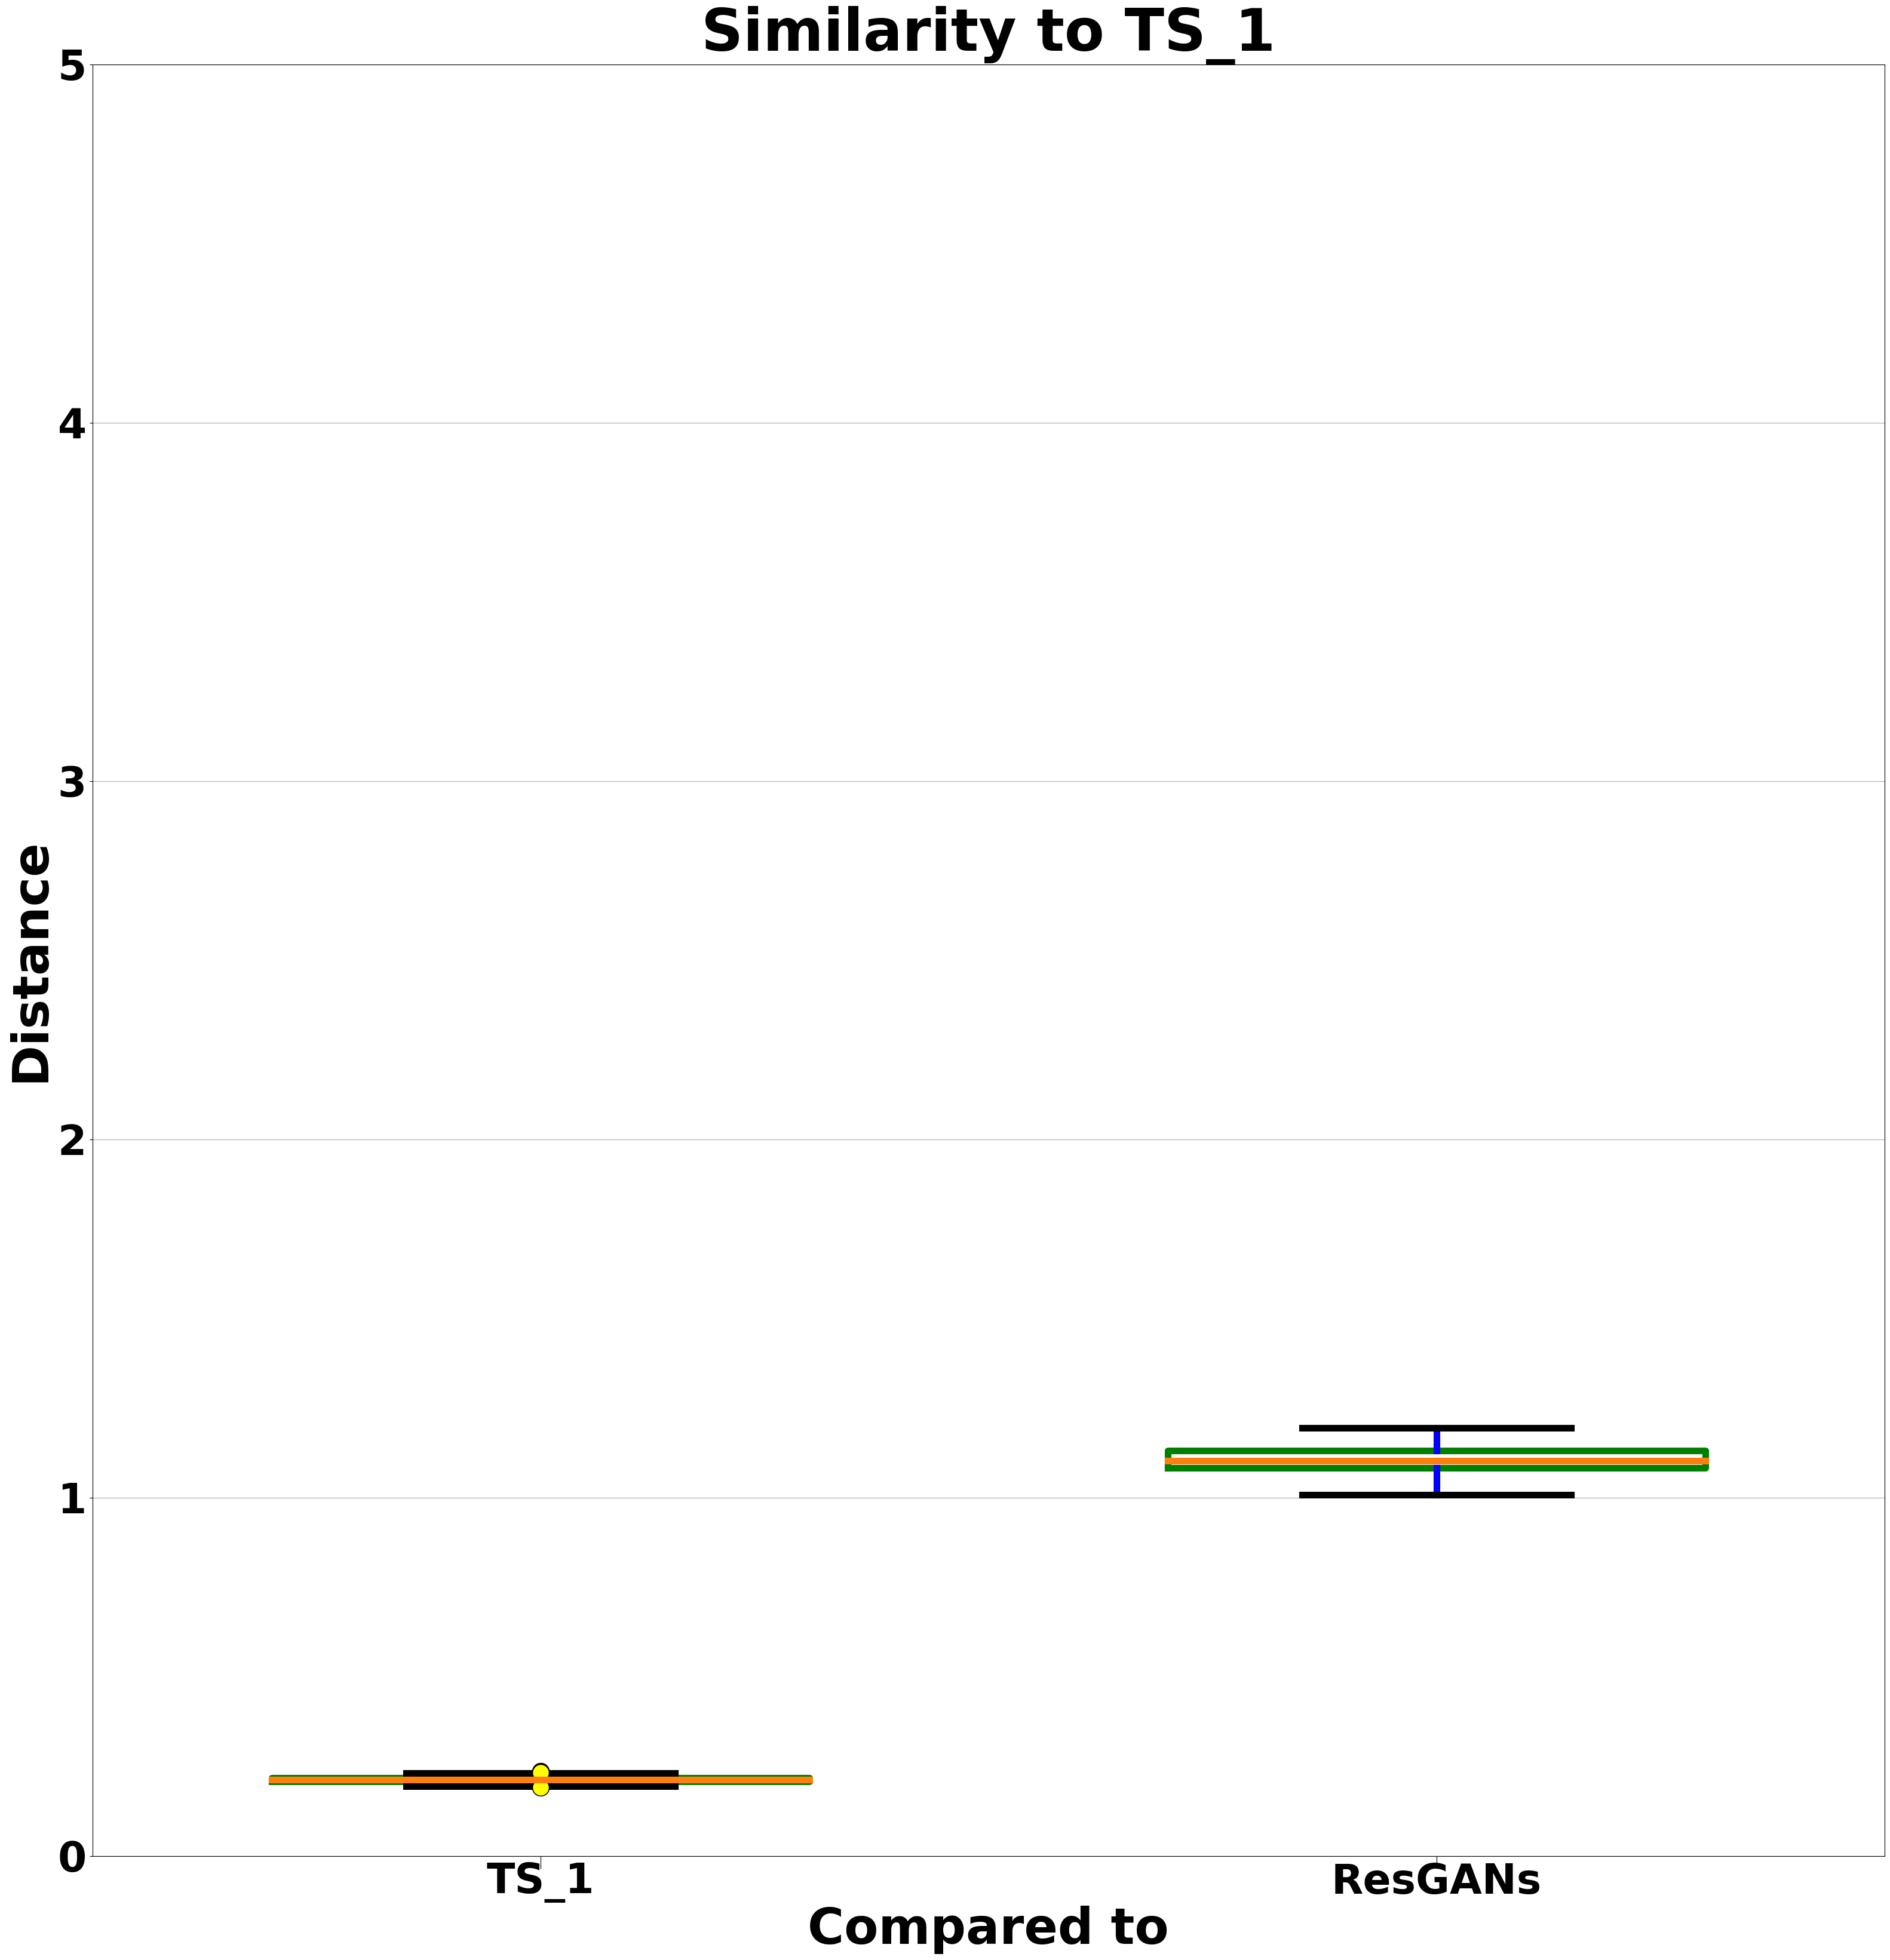

In [104]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Real_Vs_Real, "TS_1"],
                      [Real_Vs_Gen, "ResGANs"],),
                      dtype = object)

BoxPlot.boxPlotDataSeparate(dictionary, "Compared to", "Distance", "Similarity to TS_1", 
                 0.0, 5, pad)

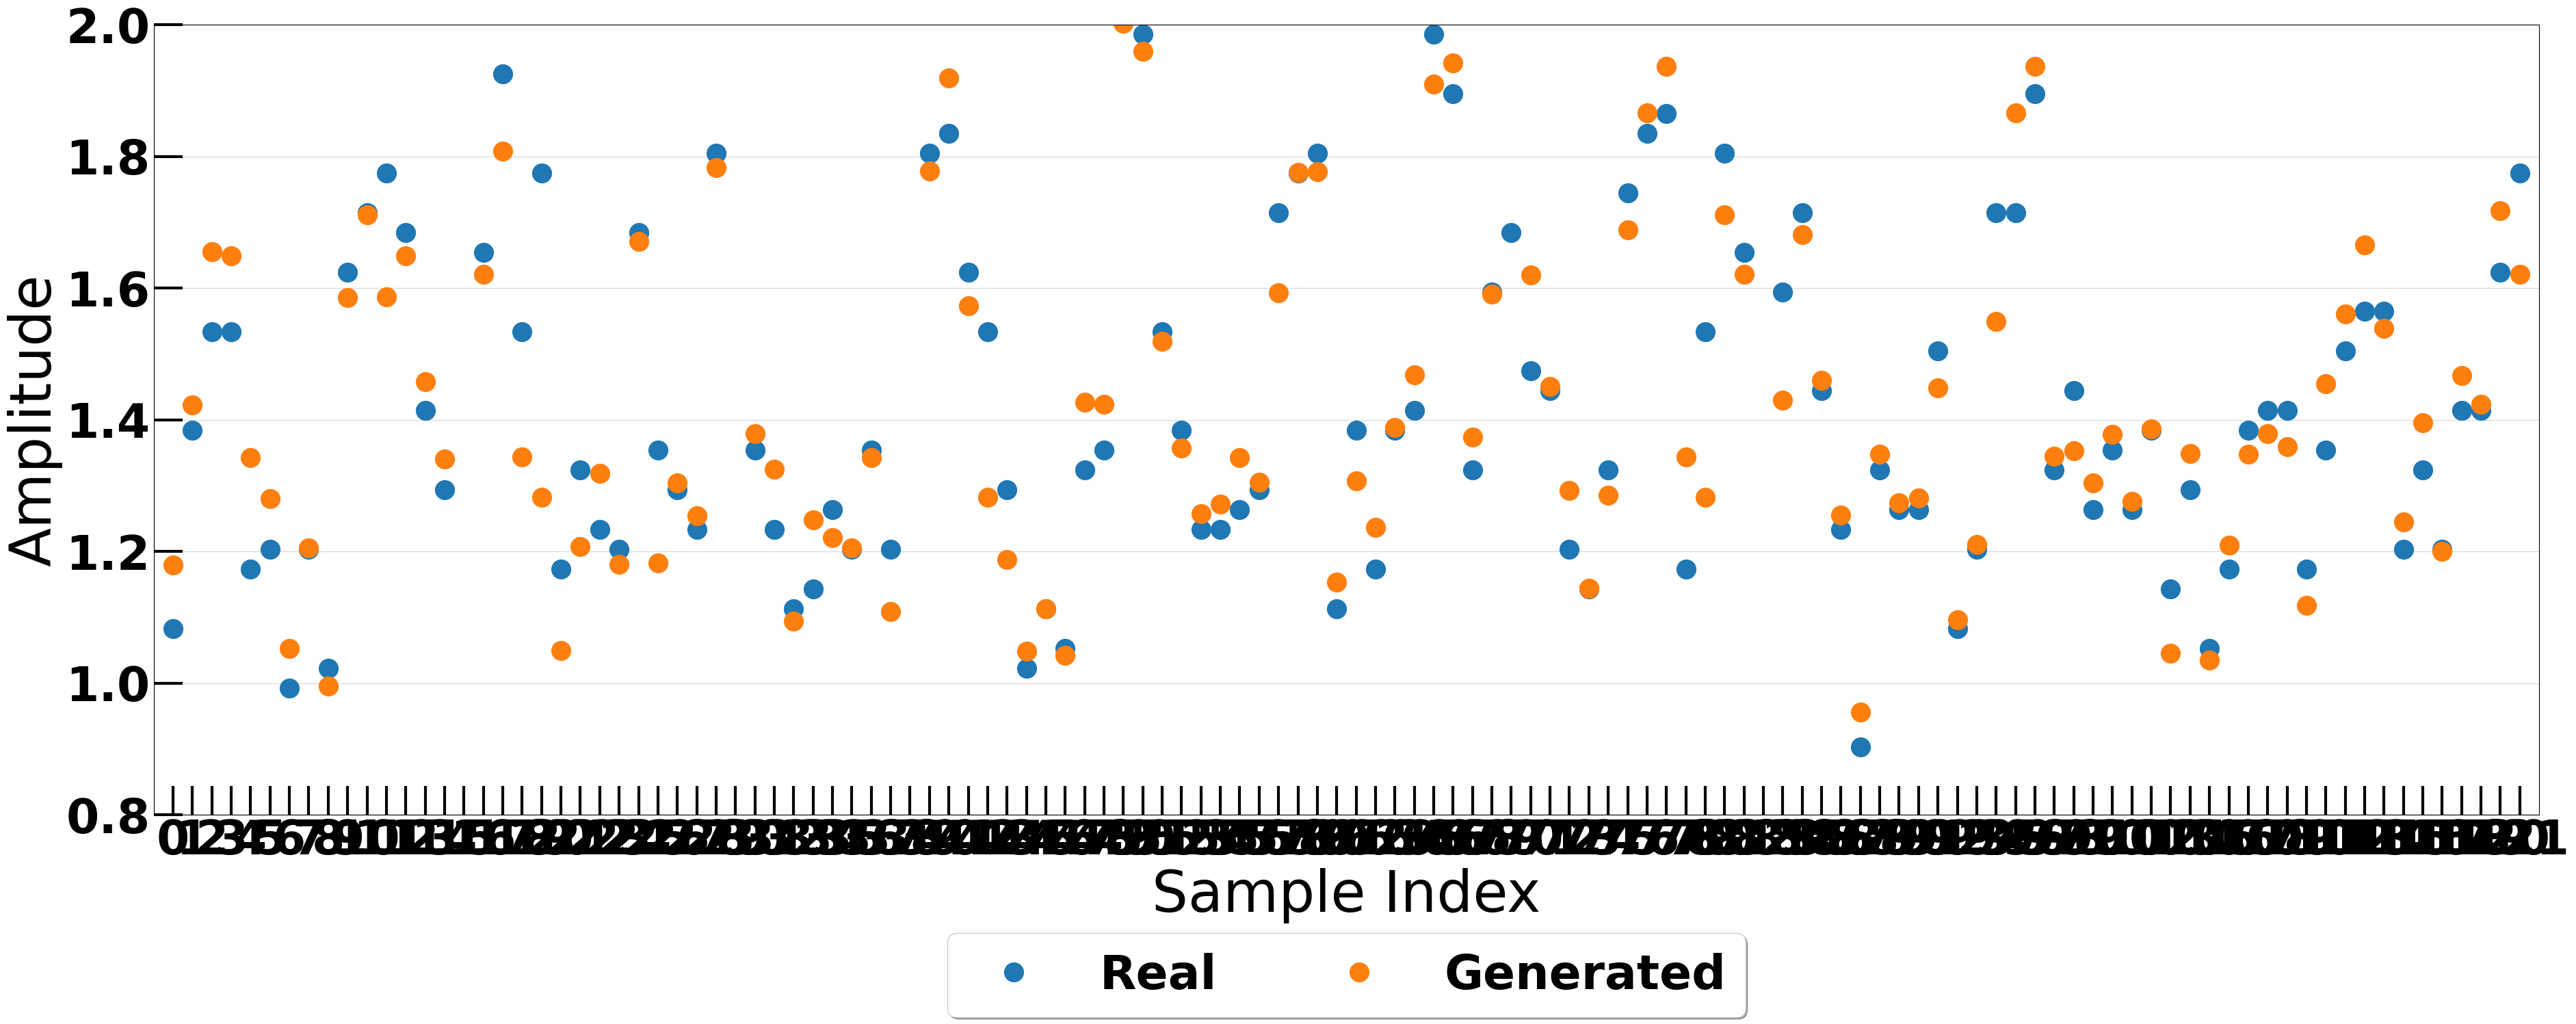

In [105]:
real_signal = TS_1[0]
fake_signal = TS_1_Gen_Signals[0]

time_Signal = np.arange(real_signal.shape[0])
plt.plot(time_Signal, real_signal, 'o', label="Real", markersize=20)
time_Signal = np.arange(fake_signal.shape[0])
plt.plot(time_Signal, fake_signal, 'o',  label="Generated", markersize=20)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(real_signal)])
plt.ylim(.8,2)
plt.xticks(np.arange(len(real_signal)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

In [106]:
print("Average Similarity for Real (TS_1): ", np.mean(Real_Vs_Real))
print("Average Similarity for Generating (TS_1): ", np.mean(Real_Vs_Gen))

Average Similarity for Real (TS_1):  0.2129099706929256
Average Similarity for Generating (TS_1):  1.10722406014092


# TS_2

In [107]:
Real_Vs_Real = pC.averageSimilarityExpReturn(TS_2[0:1500], TS_2[1500:3000], "Real_1", "Real_2", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [108]:
Real_Vs_Gen = pC.averageSimilarityExpReturn(TS_2[0:1500], TS_2_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

(1500,)


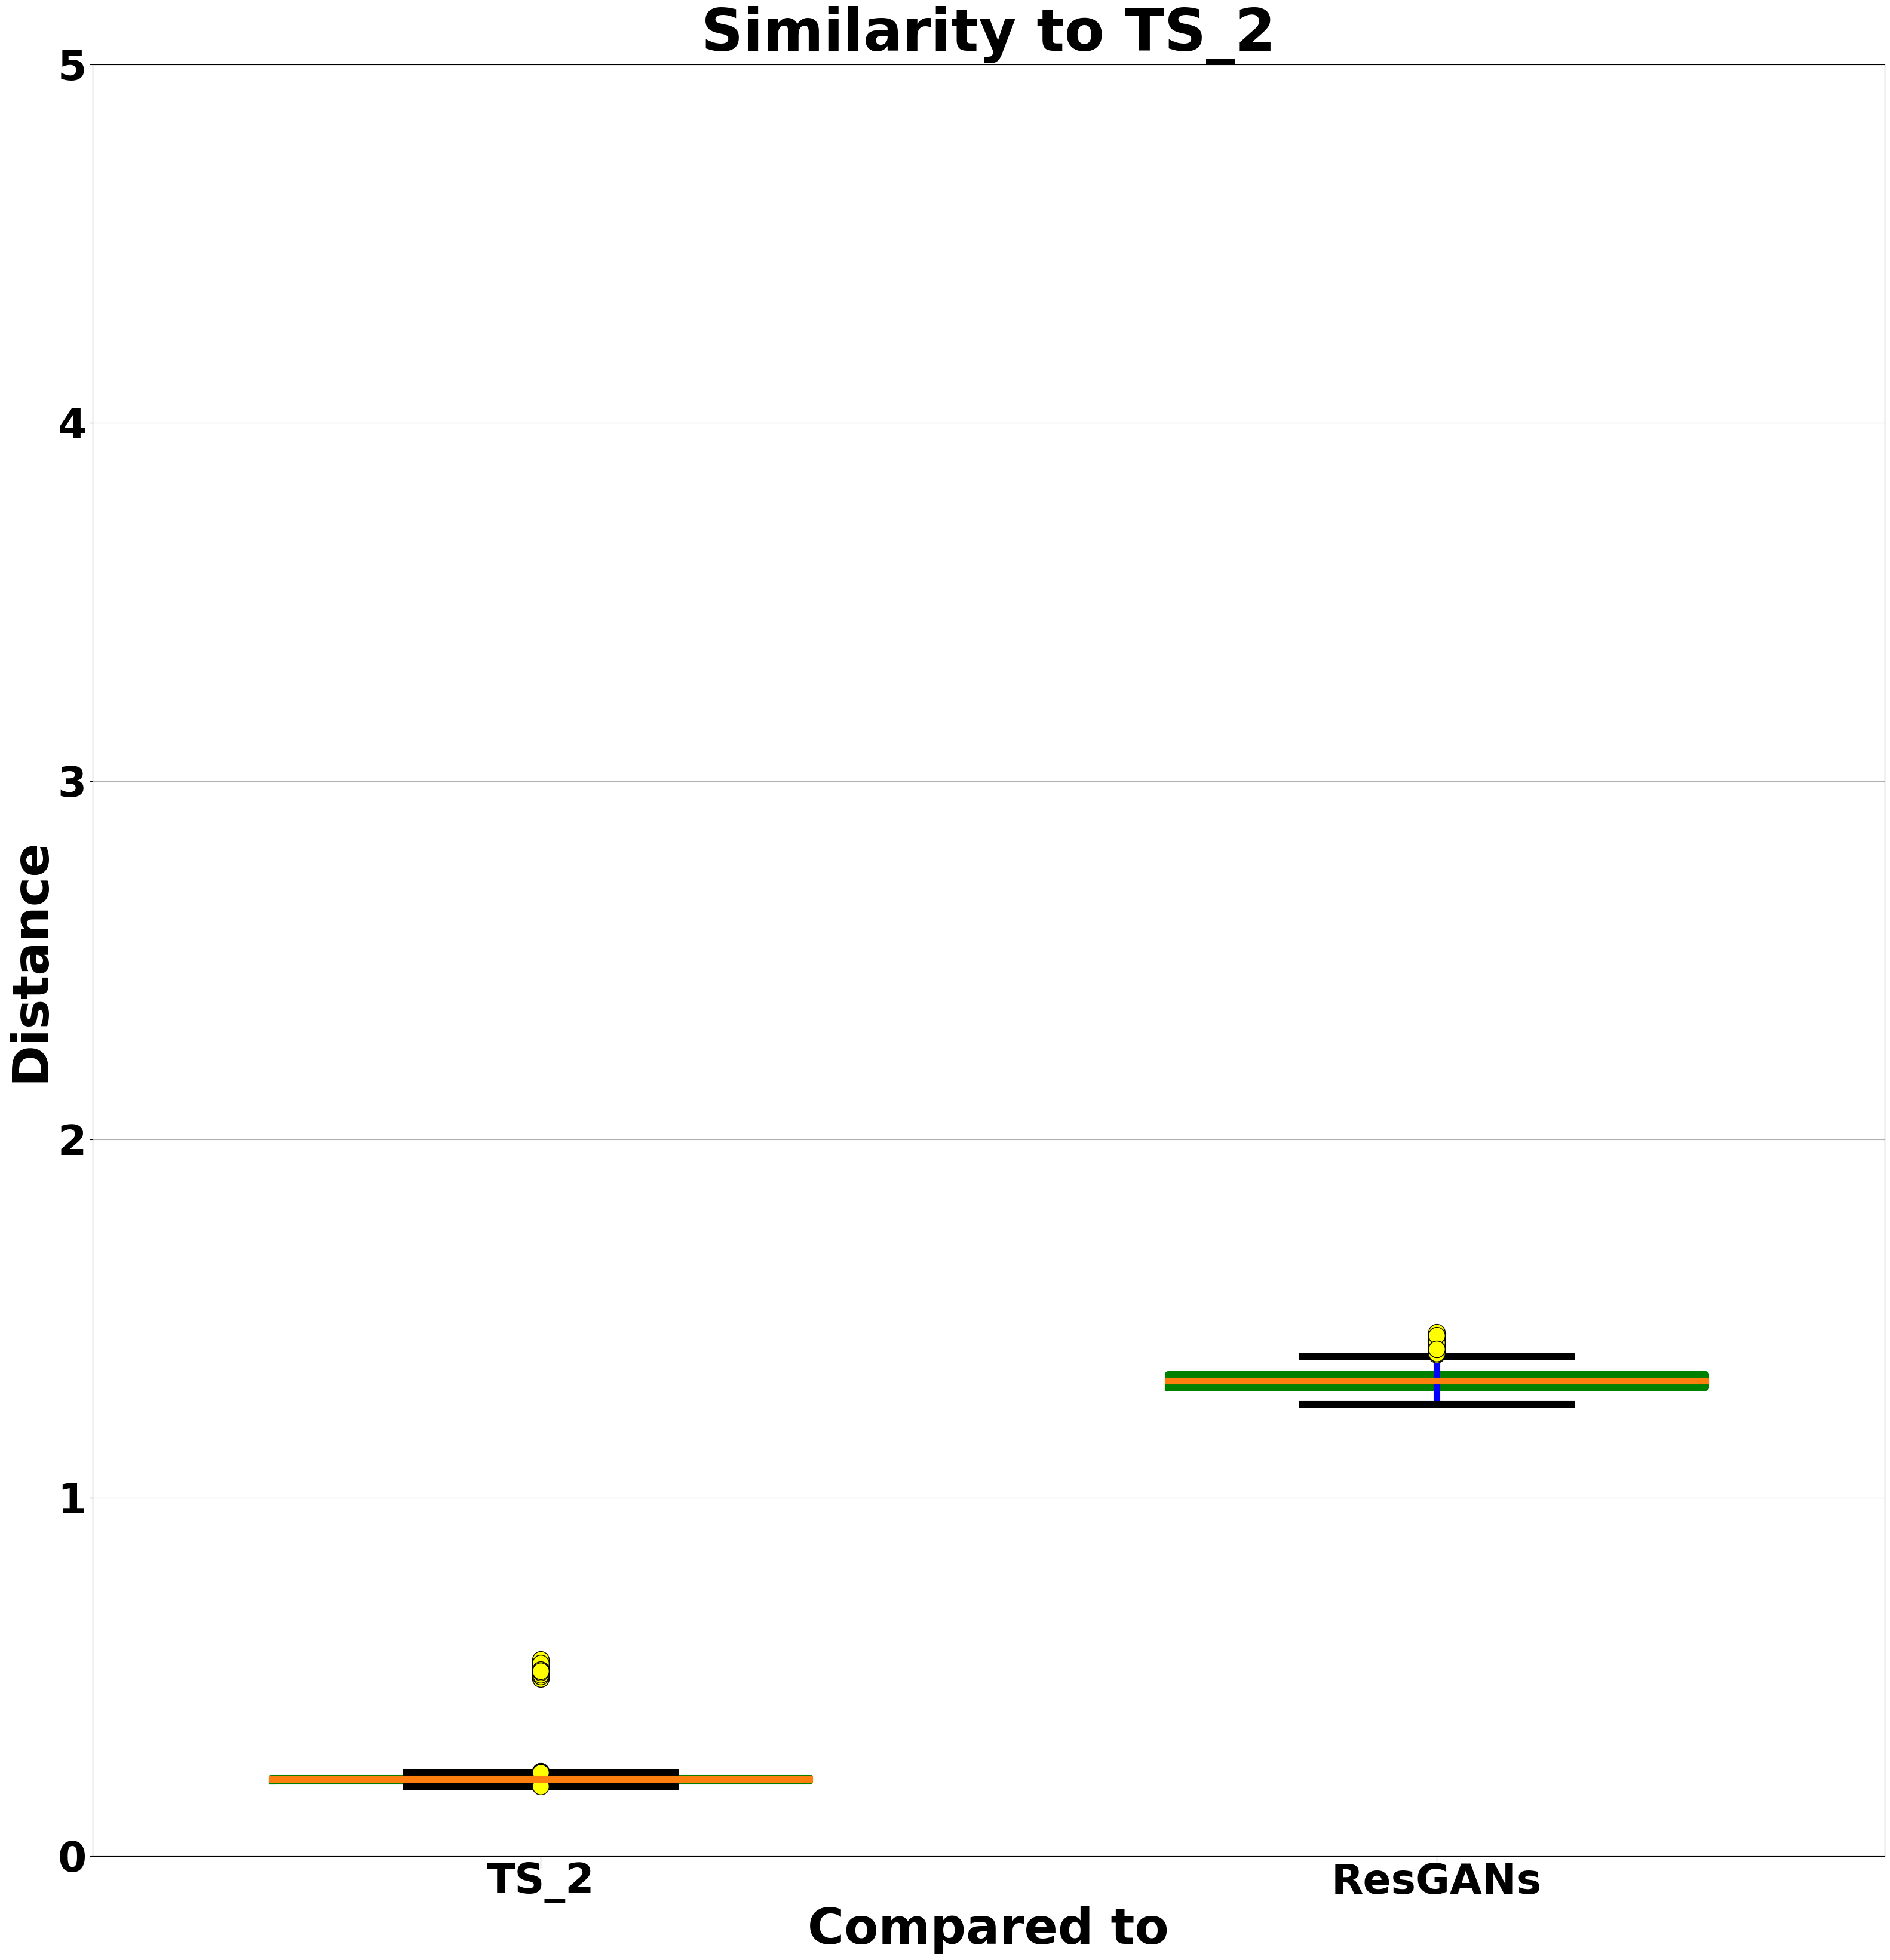

In [109]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Real_Vs_Real, "TS_2"],
                      [Real_Vs_Gen, "ResGANs"],),
                      dtype = object)

BoxPlot.boxPlotDataSeparate(dictionary, "Compared to", "Distance", "Similarity to TS_2", 
                 0.0, 5, pad)

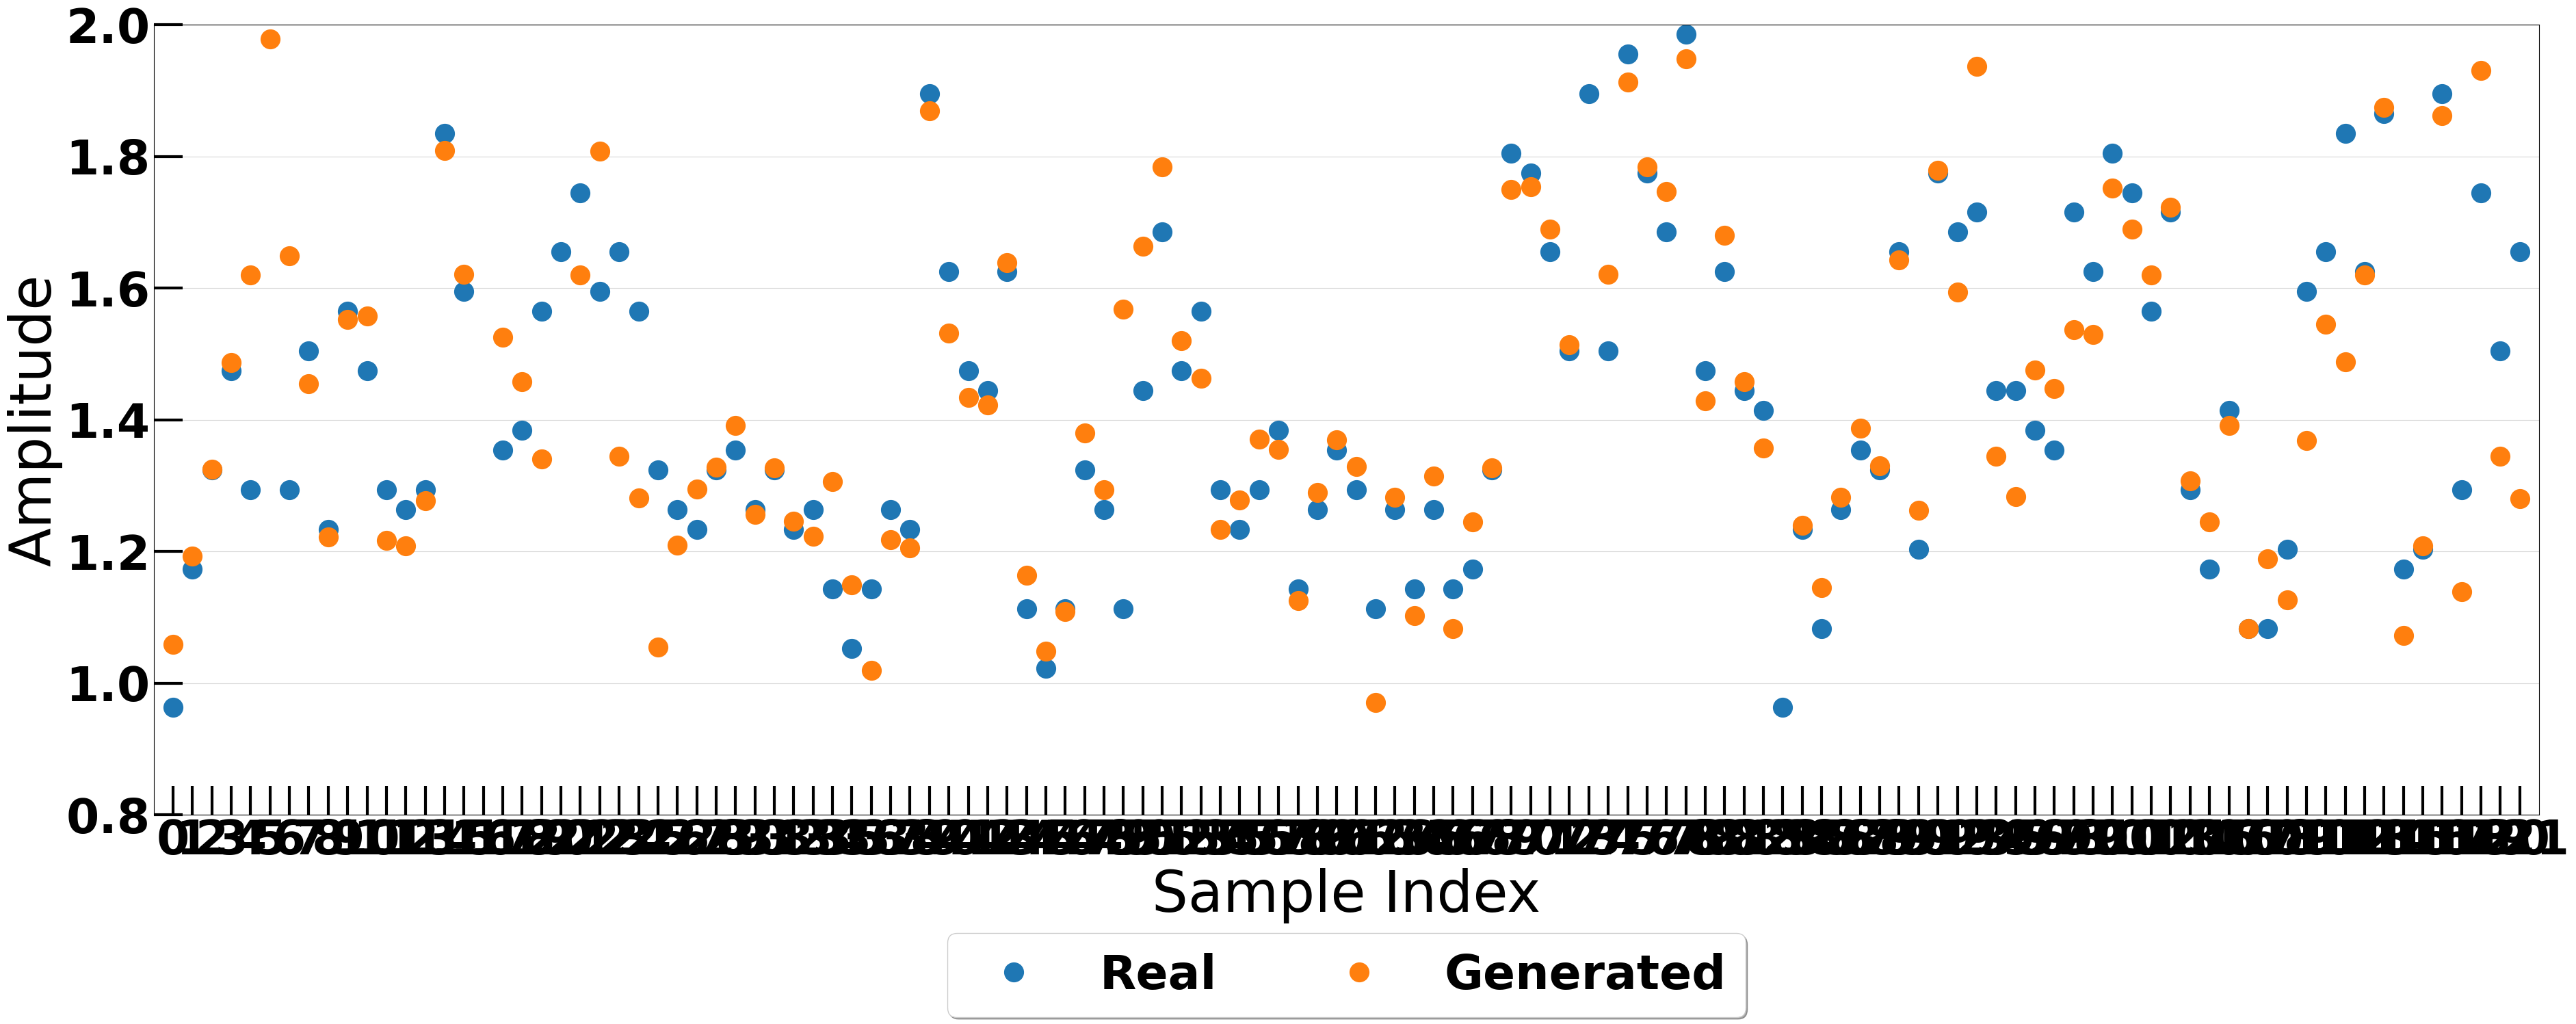

In [110]:
real_signal = TS_2[0]
fake_signal = TS_2_Gen_Signals[0]

time_Signal = np.arange(real_signal.shape[0])
plt.plot(time_Signal, real_signal, 'o', label="Real", markersize=20)
time_Signal = np.arange(fake_signal.shape[0])
plt.plot(time_Signal, fake_signal, 'o',  label="Generated", markersize=20)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(real_signal)])
plt.ylim(.8,2)
plt.xticks(np.arange(len(real_signal)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

In [111]:
print("Average Similarity for Real (TS_2): ", np.mean(Real_Vs_Real))
print("Average Similarity for Generating (TS_2): ", np.mean(Real_Vs_Gen))

Average Similarity for Real (TS_2):  0.21850912212889098
Average Similarity for Generating (TS_2):  1.3263684597760288


# TS_3

In [112]:
Real_Vs_Real = pC.averageSimilarityExpReturn(TS_3[0:1500], TS_3[1500:3000], "Real_1", "Real_2", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [113]:
Real_Vs_Gen = pC.averageSimilarityExpReturn(TS_3[0:1500], TS_3_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

(1500,)


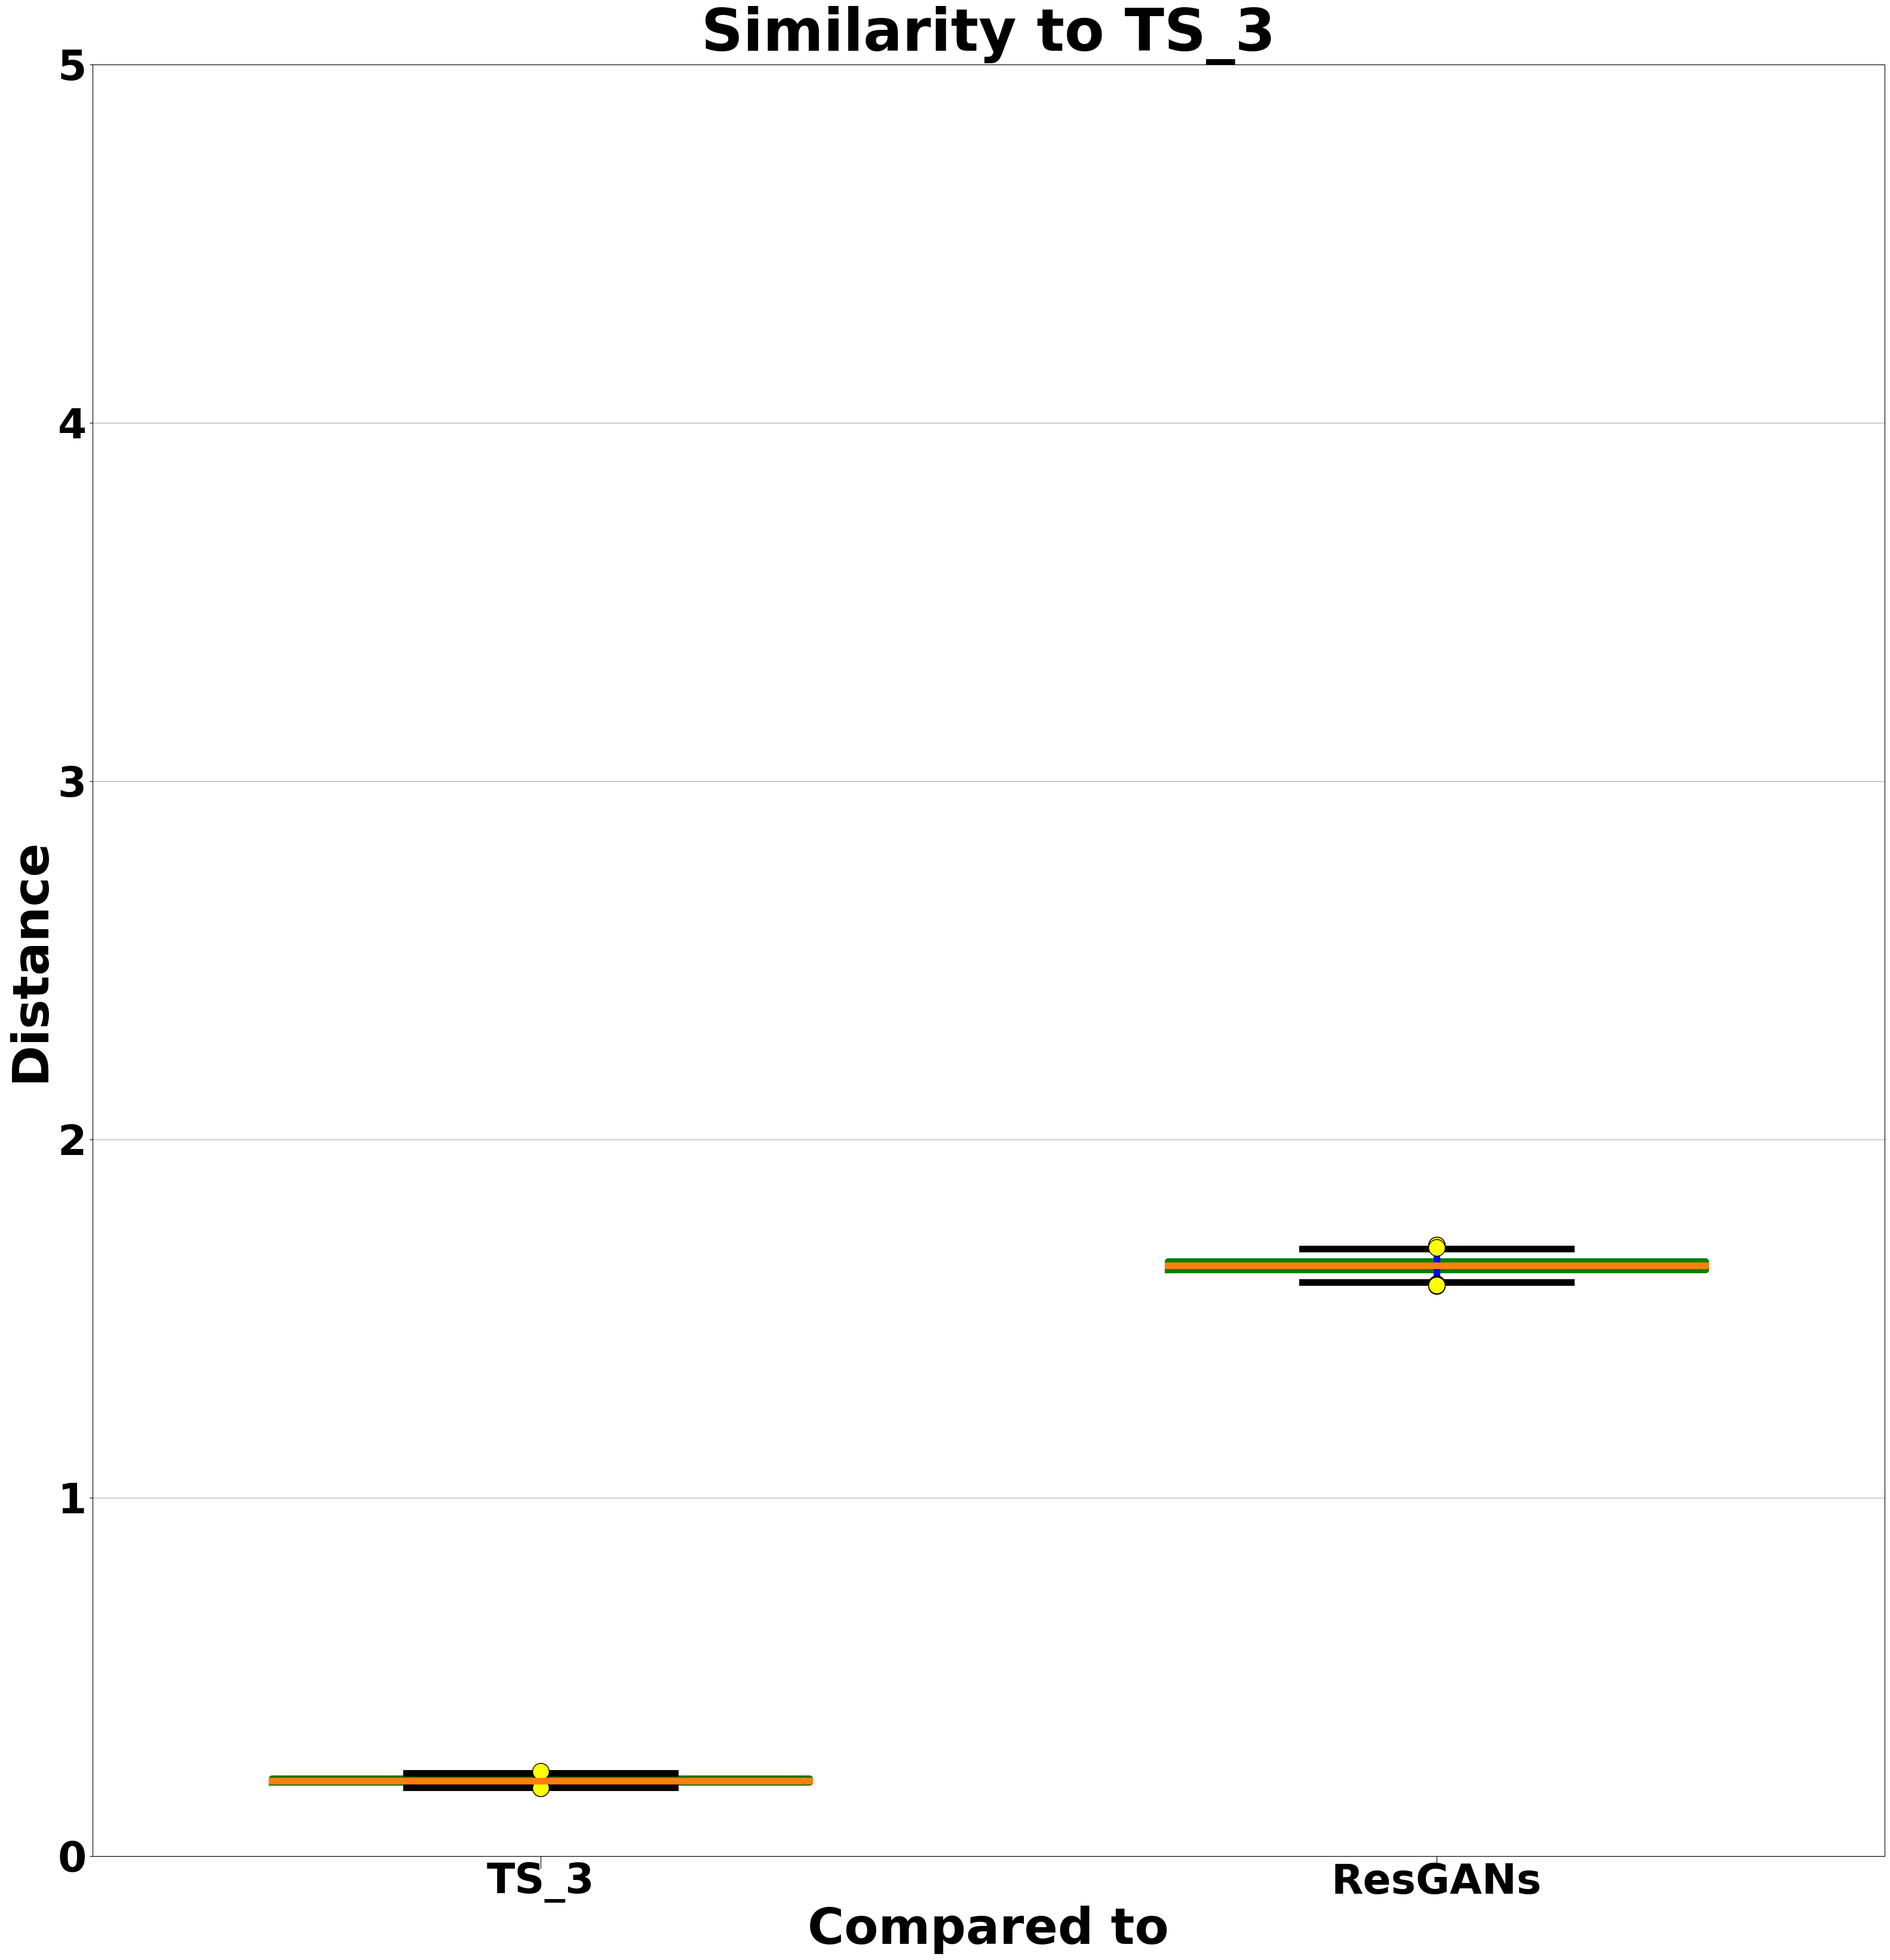

In [114]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Real_Vs_Real, "TS_3"],
                      [Real_Vs_Gen, "ResGANs"],),
                      dtype = object)

BoxPlot.boxPlotDataSeparate(dictionary, "Compared to", "Distance", "Similarity to TS_3", 
                 0.0, 5, pad)

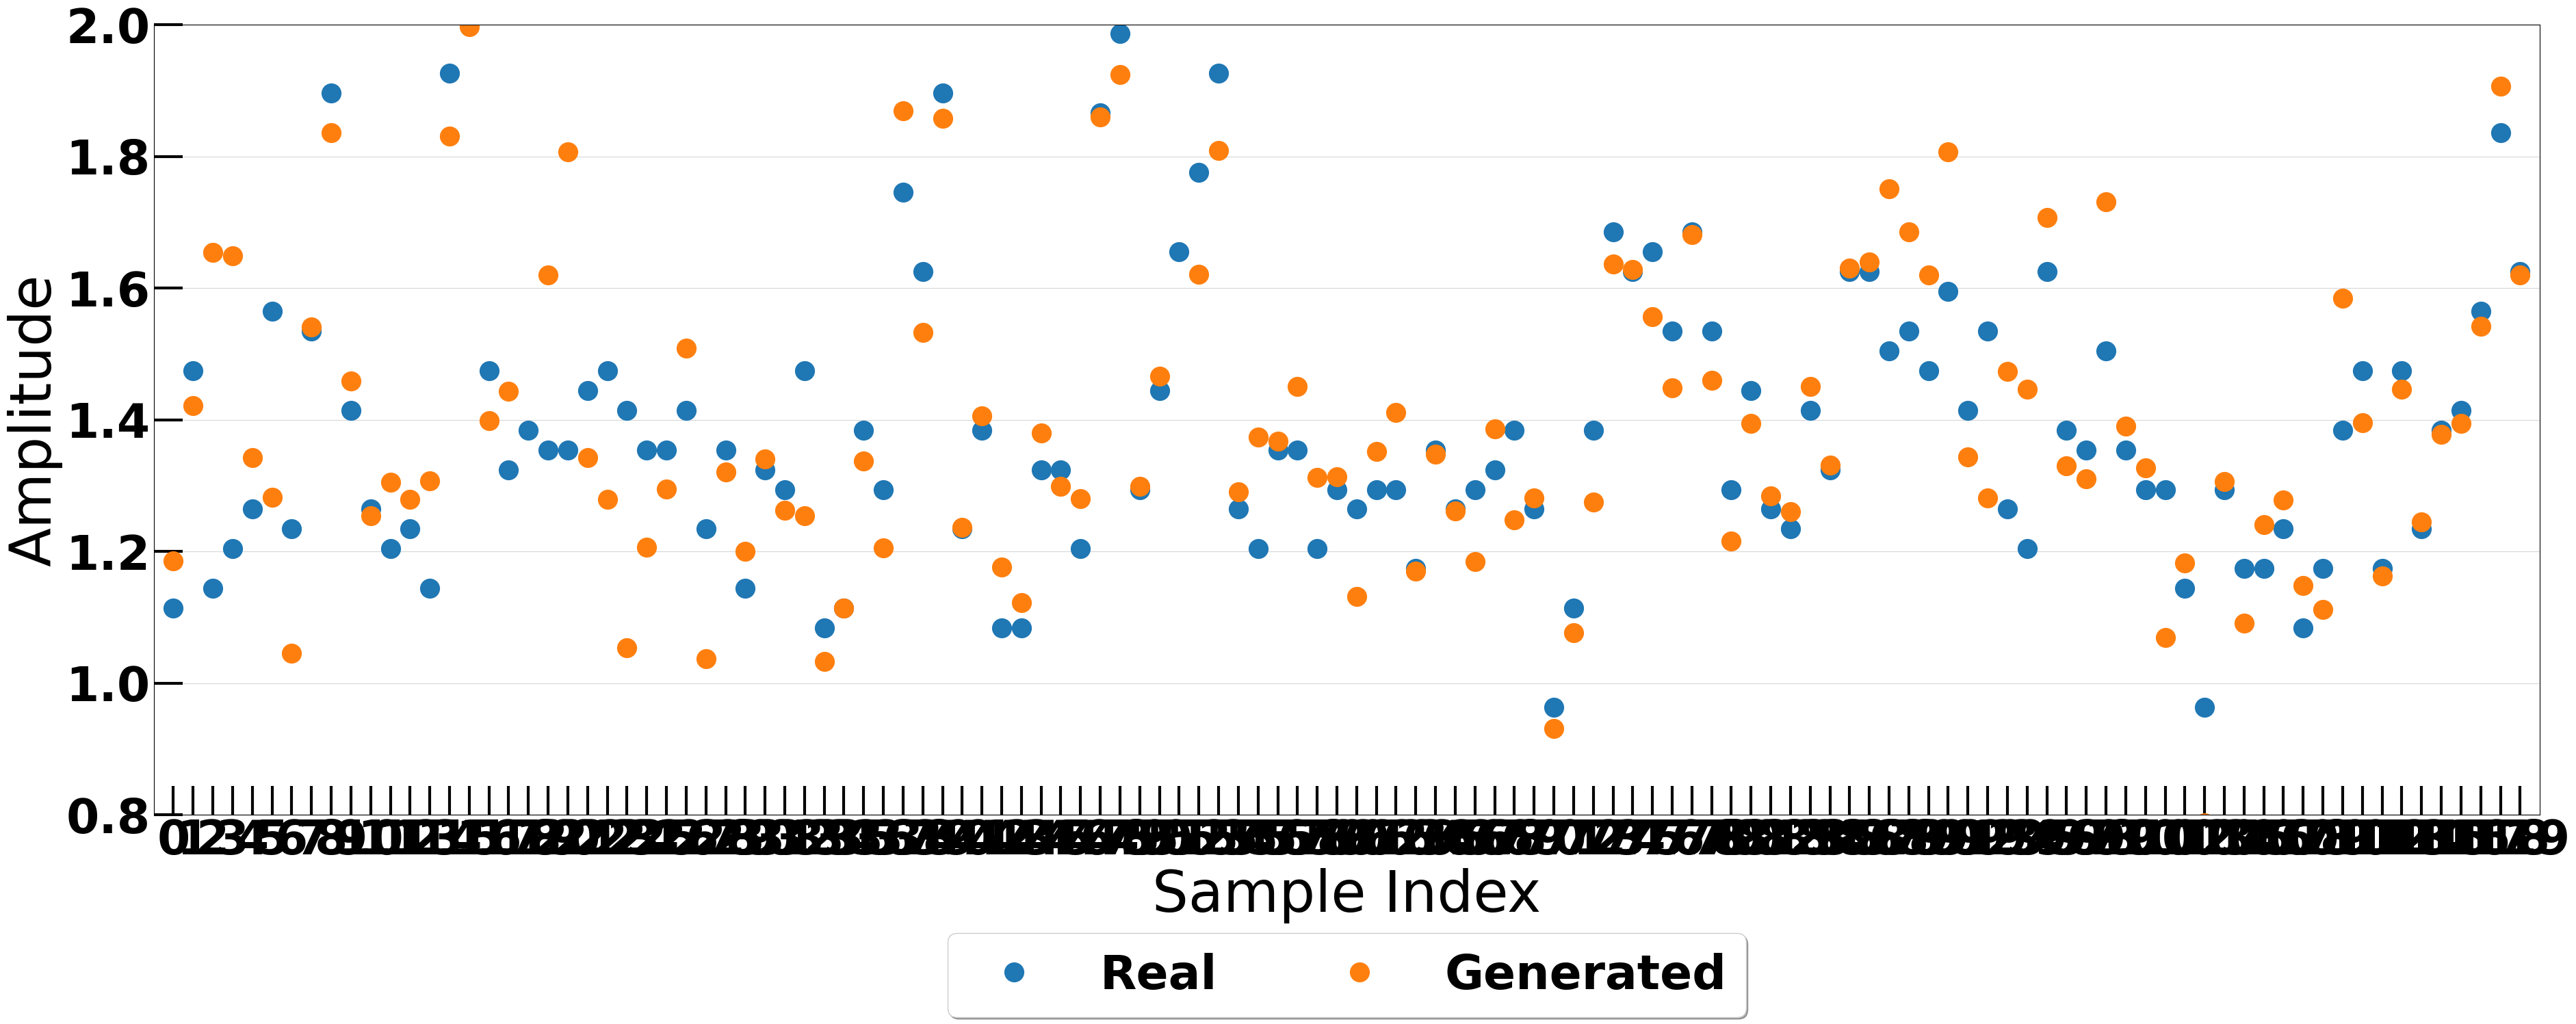

In [115]:
real_signal = TS_3[0]
fake_signal = TS_3_Gen_Signals[0]

time_Signal = np.arange(real_signal.shape[0])
plt.plot(time_Signal, real_signal, 'o', label="Real", markersize=20)
time_Signal = np.arange(fake_signal.shape[0])
plt.plot(time_Signal, fake_signal, 'o',  label="Generated", markersize=20)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(real_signal)])
plt.ylim(.8,2)
plt.xticks(np.arange(len(real_signal)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

In [116]:
print("Average Similarity for Real (TS_3): ", np.mean(Real_Vs_Real))
print("Average Similarity for Generating (TS_3): ", np.mean(Real_Vs_Gen))

Average Similarity for Real (TS_3):  0.21062786054587693
Average Similarity for Generating (TS_3):  1.6475894201911838


# TS_4

In [123]:
Real_Vs_Real = pC.averageSimilarityExpReturn(TS_4[0:1500], TS_4[1500:3000], "Real_1", "Real_2", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [122]:
Real_Vs_Gen = pC.averageSimilarityExpReturn(TS_4[0:1500], TS_4_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

(1500,)


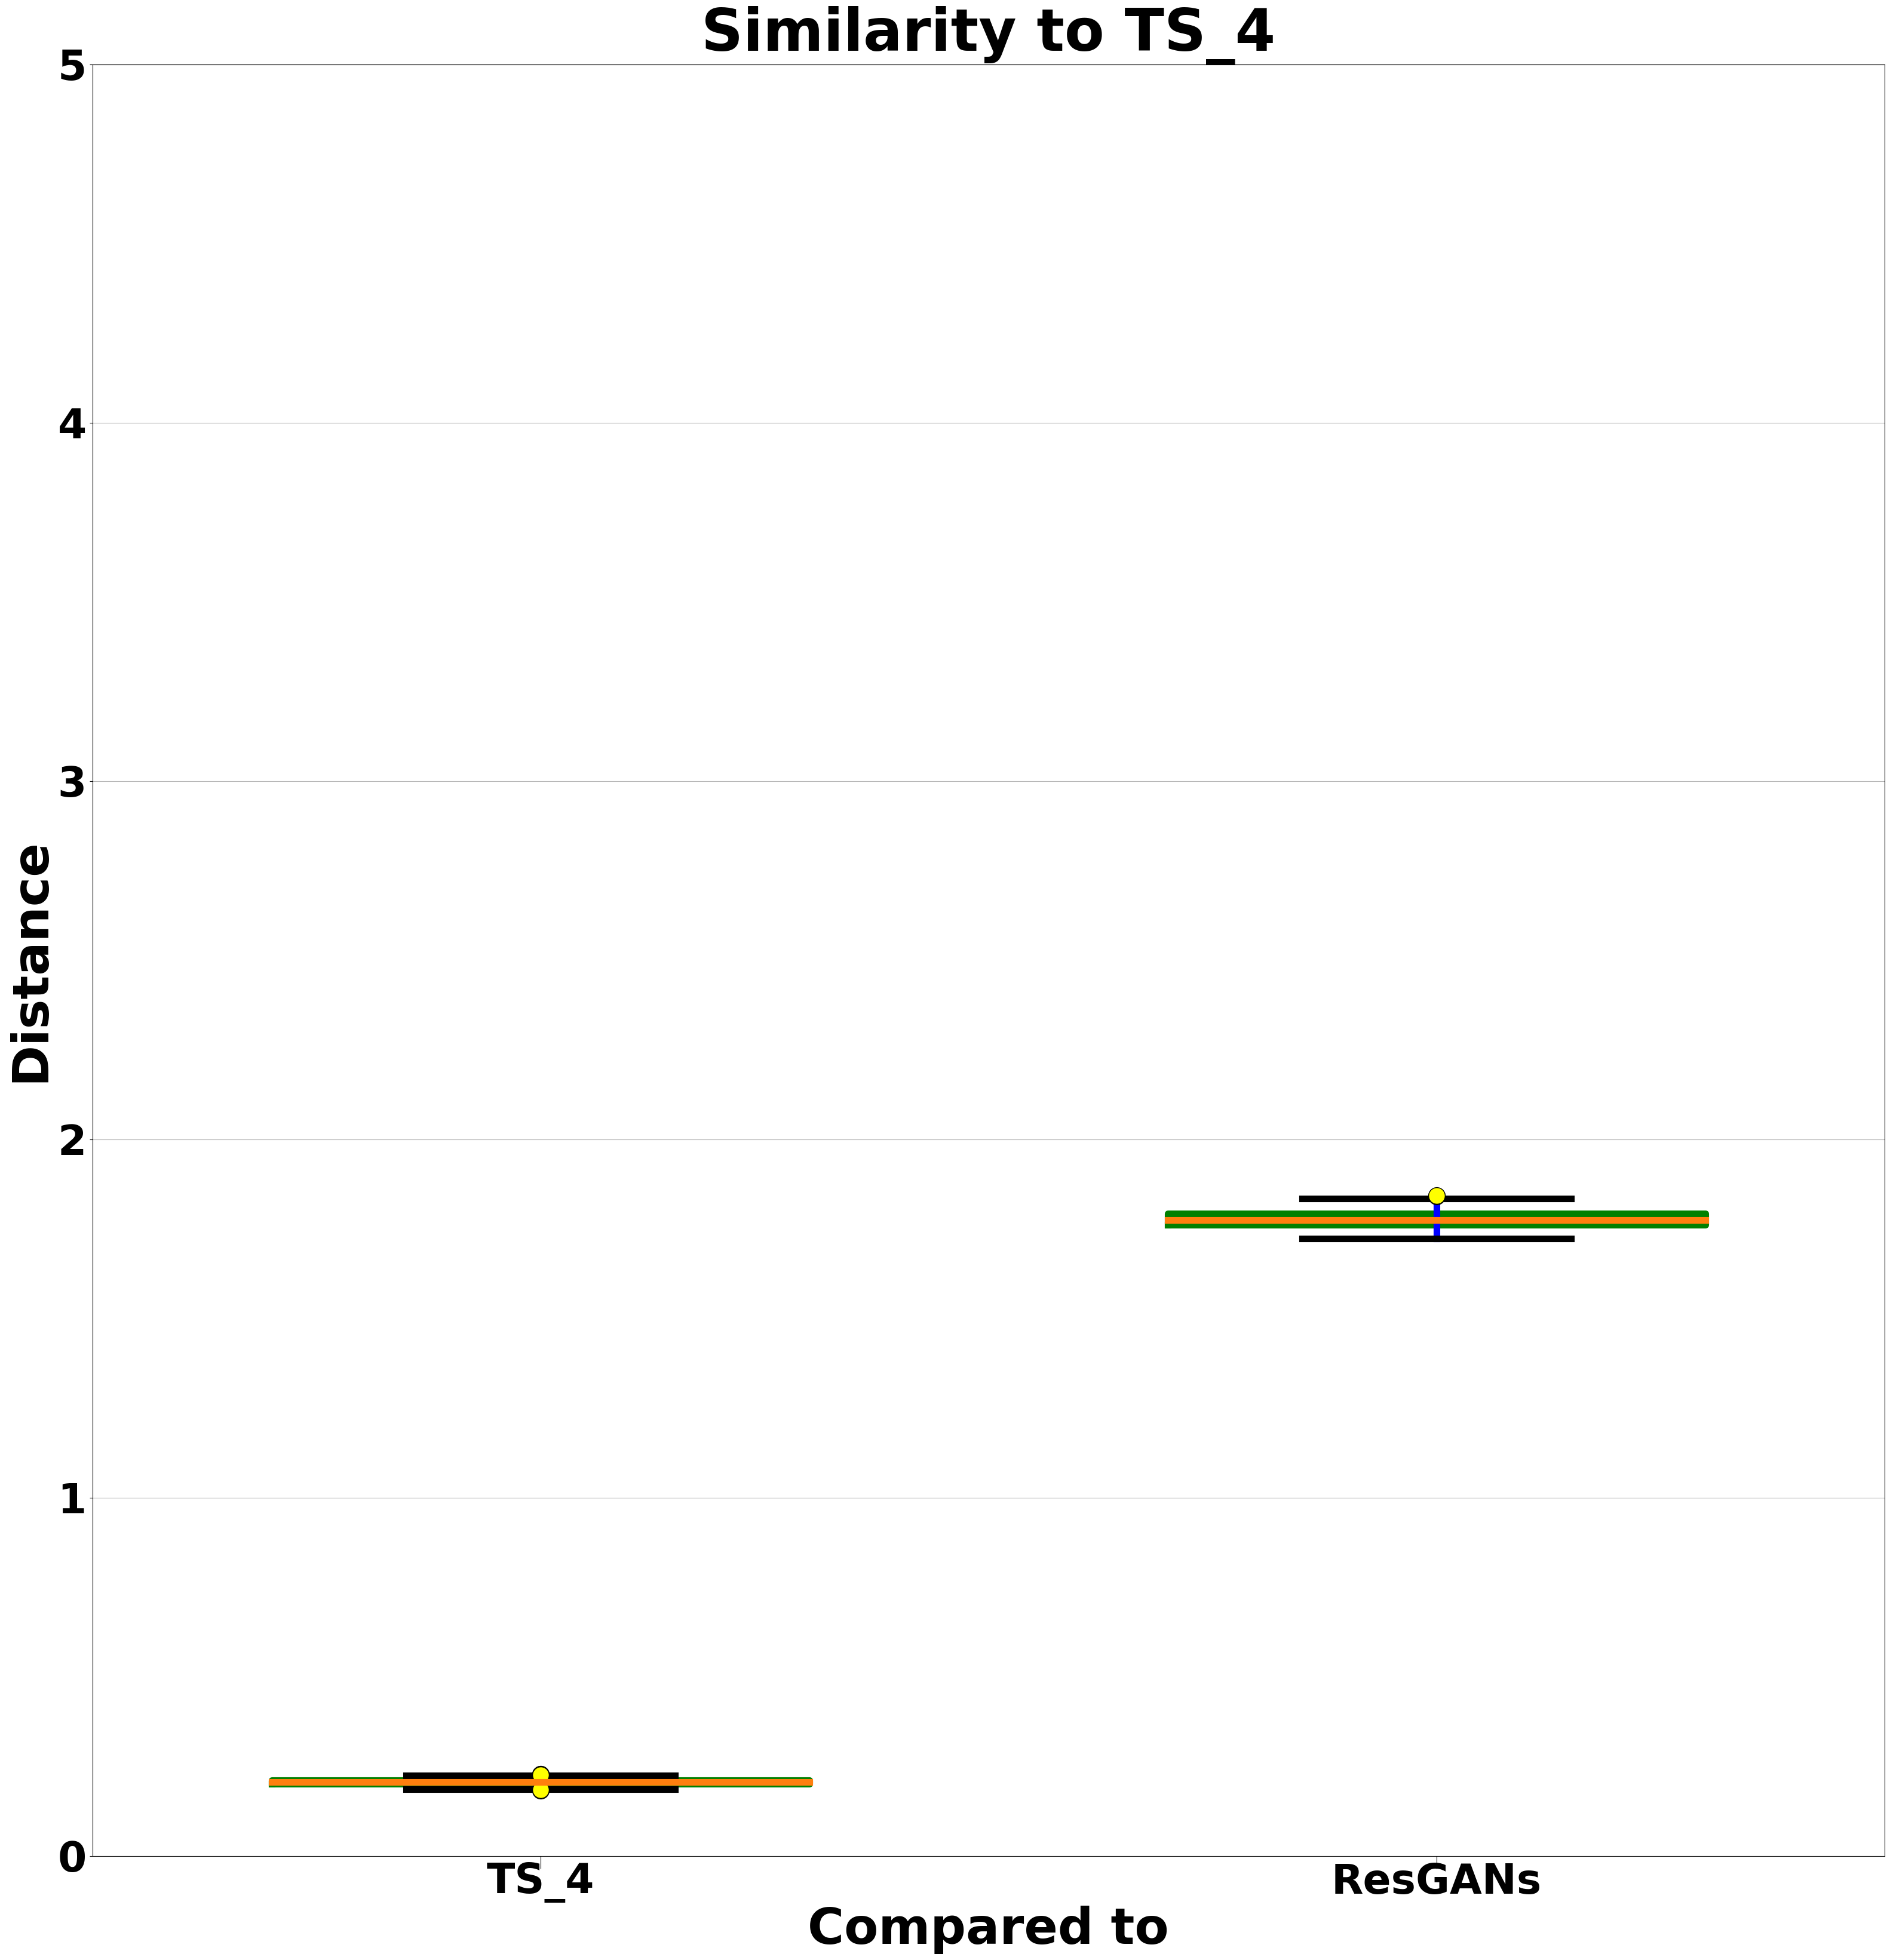

In [124]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Real_Vs_Real, "TS_4"],
                      [Real_Vs_Gen, "ResGANs"],),
                      dtype = object)

BoxPlot.boxPlotDataSeparate(dictionary, "Compared to", "Distance", "Similarity to TS_4", 
                 0.0, 5, pad)

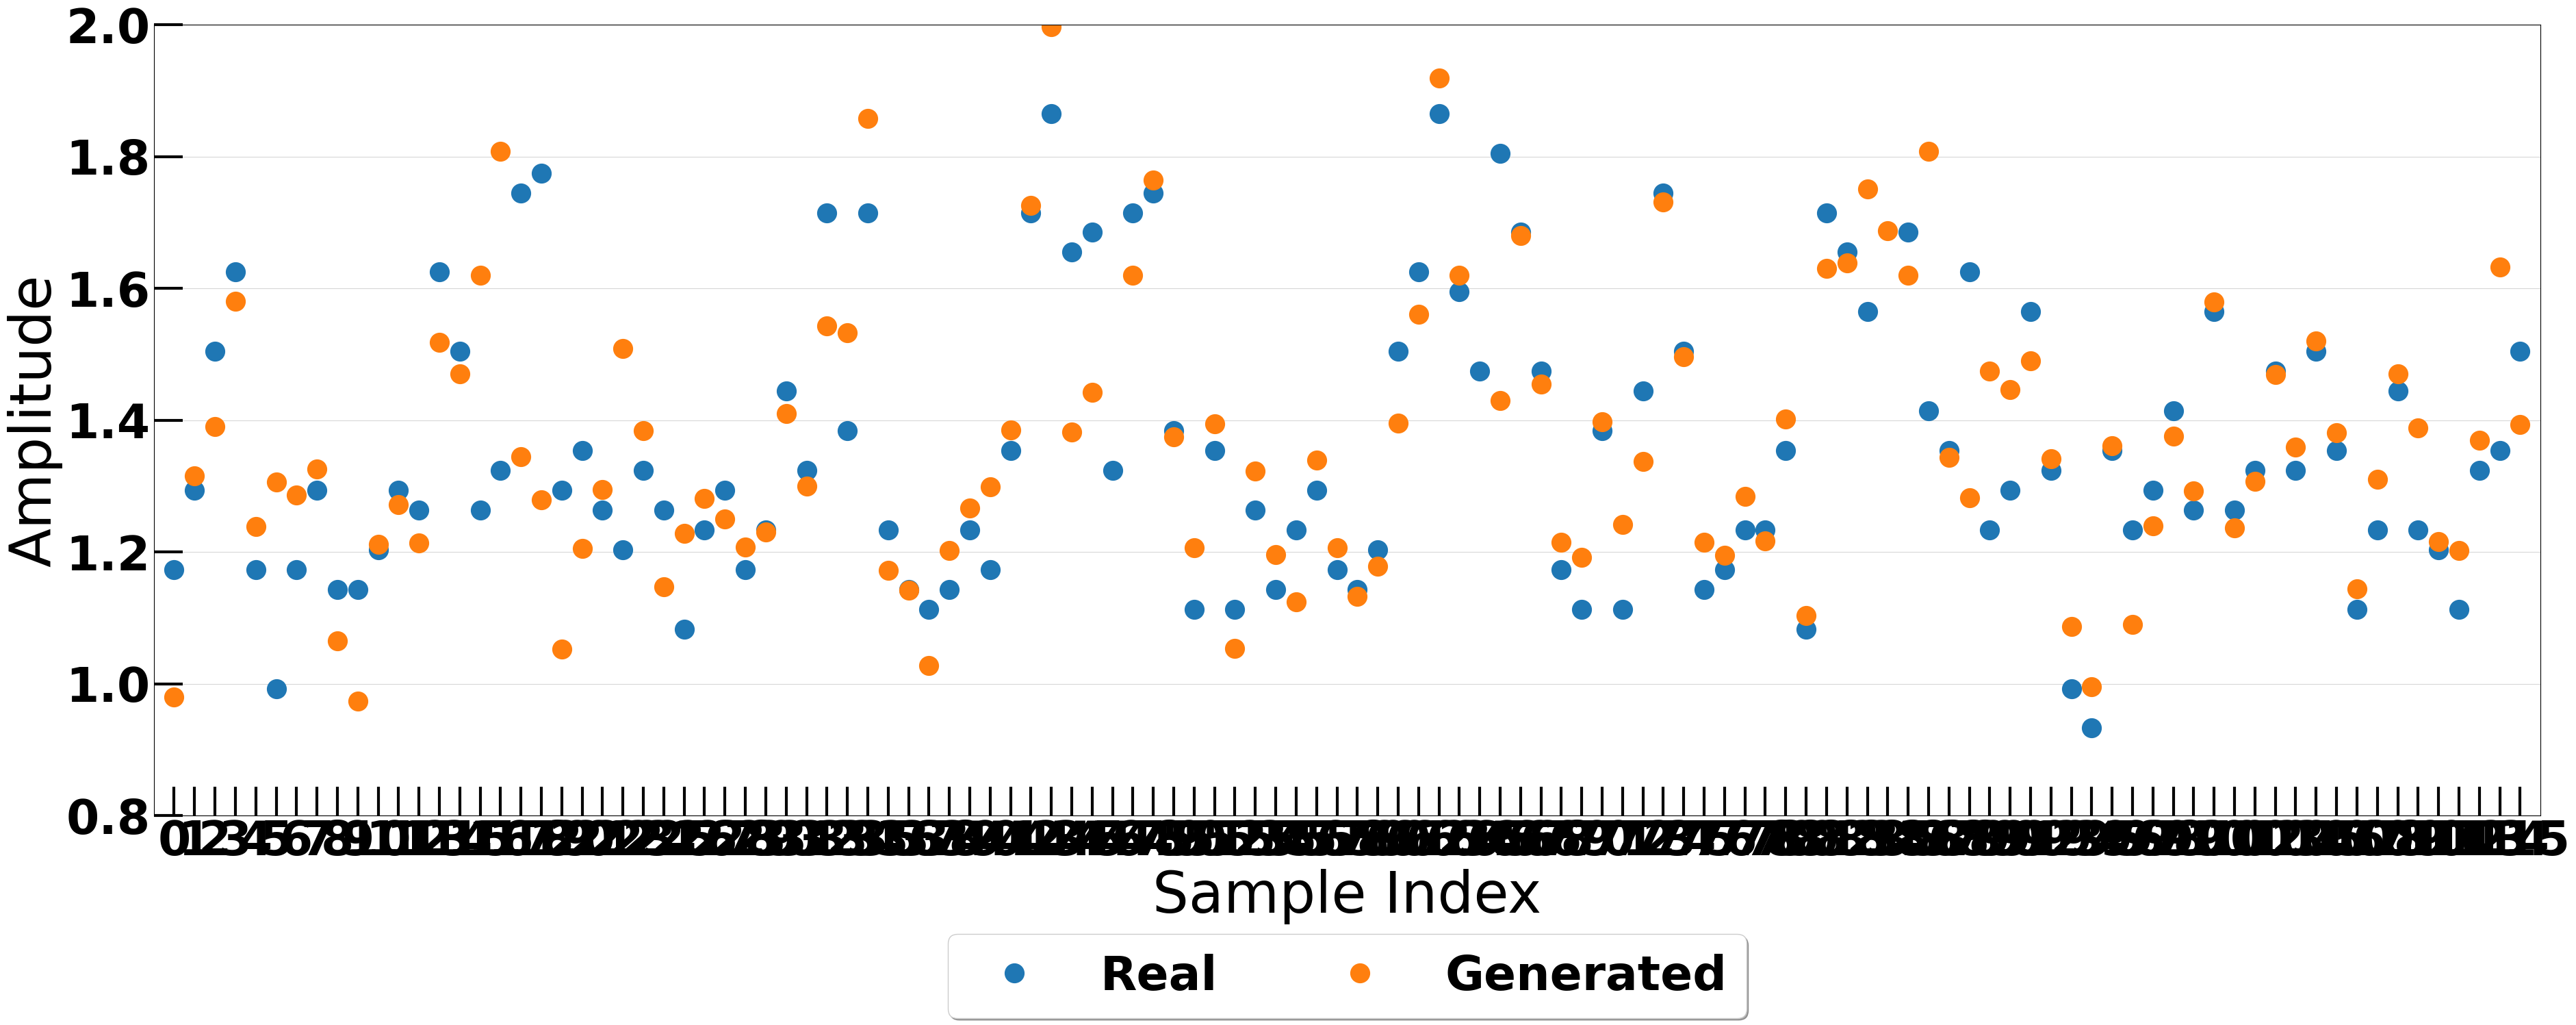

In [125]:
real_signal = TS_4[0]
fake_signal = TS_4_Gen_Signals[0]

time_Signal = np.arange(real_signal.shape[0])
plt.plot(time_Signal, real_signal, 'o', label="Real", markersize=20)
time_Signal = np.arange(fake_signal.shape[0])
plt.plot(time_Signal, fake_signal, 'o',  label="Generated", markersize=20)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(real_signal)])
plt.ylim(.8,2)
plt.xticks(np.arange(len(real_signal)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

In [126]:
print("Average Similarity for Real (TS_4): ", np.mean(Real_Vs_Real))
print("Average Similarity for Generating (TS_4): ", np.mean(Real_Vs_Gen))

Average Similarity for Real (TS_4):  0.20556472832743308
Average Similarity for Generating (TS_4):  1.777155306825569


# TS_5

In [127]:
Real_Vs_Real = pC.averageSimilarityExpReturn(TS_5[0:1500], TS_5[1500:3000], "Real_1", "Real_2", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

In [128]:
Real_Vs_Gen = pC.averageSimilarityExpReturn(TS_5[0:1500], TS_5_Gen_Signals[0:1500], "Real", "fake", pad, 
                            np.array([0]), 4, amtGraphs = 0, topNumSim=np.array([25]), nonPeakEnds = False, Info= False,
                                            PeakOnlyData=True)

(1500,)


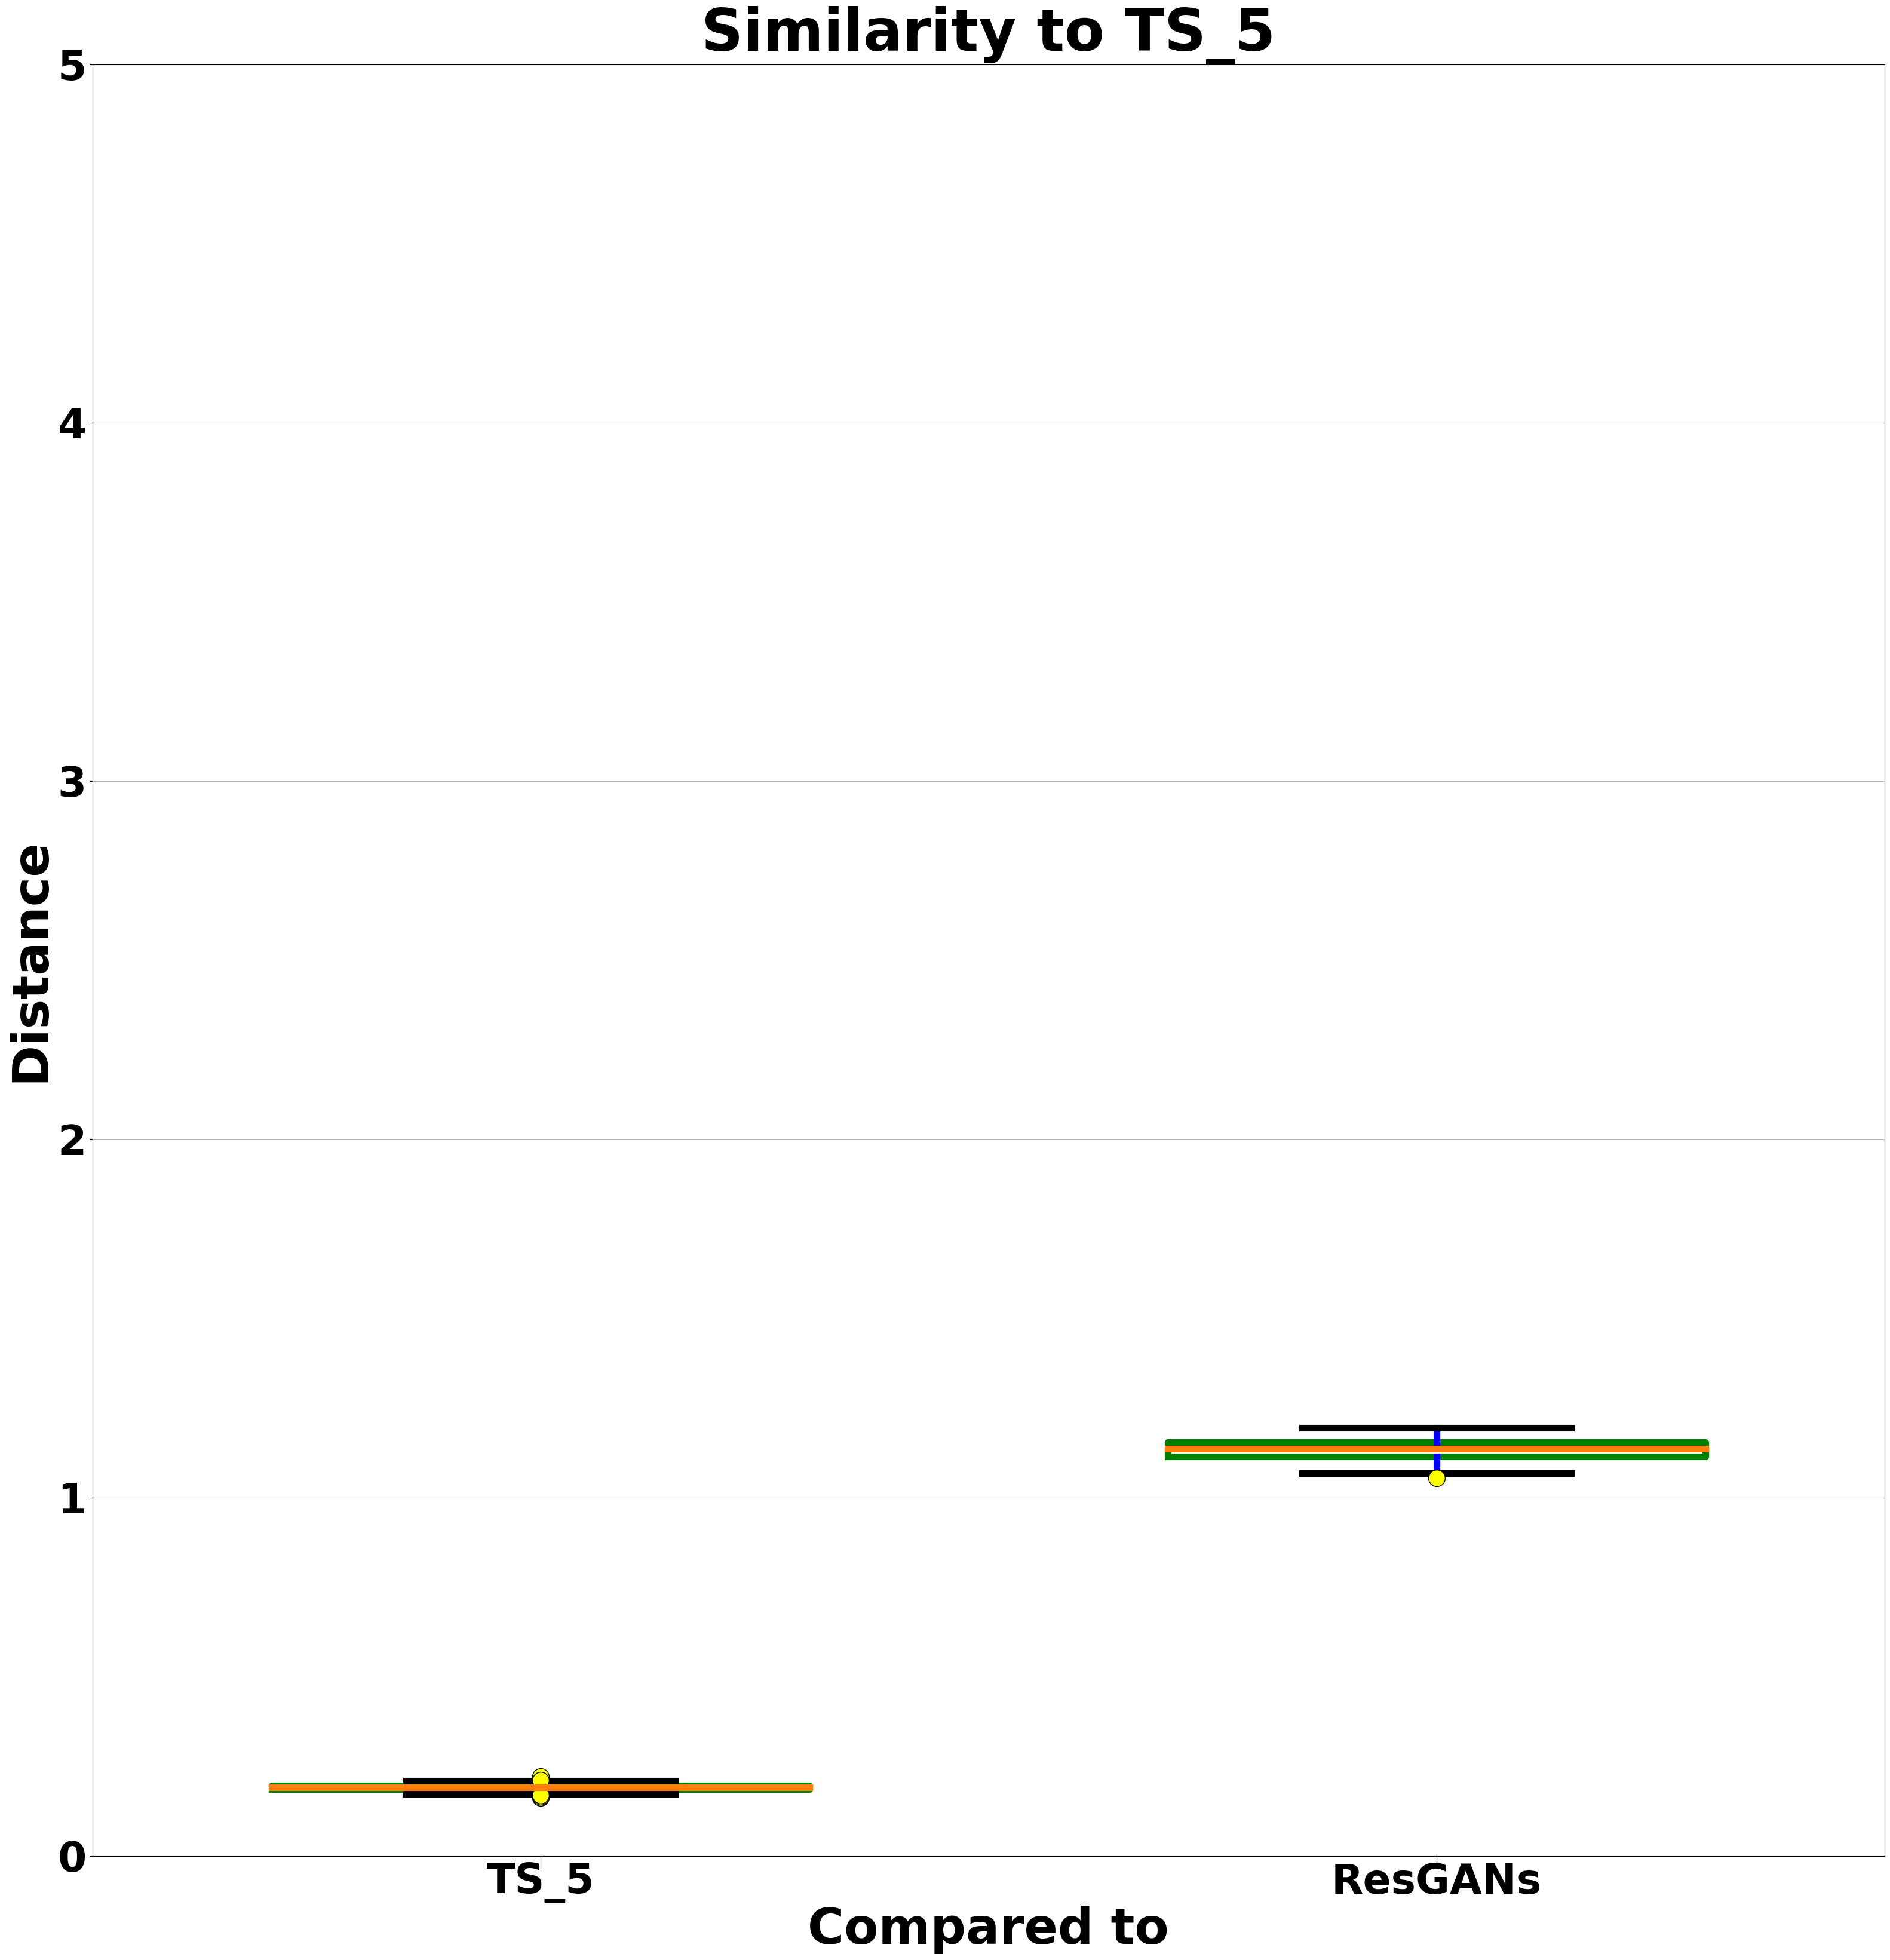

In [129]:
# Dictionary should contain: [Signals, peakLoc, name]
dictionary = np.array(([Real_Vs_Real, "TS_5"],
                      [Real_Vs_Gen, "ResGANs"],),
                      dtype = object)

BoxPlot.boxPlotDataSeparate(dictionary, "Compared to", "Distance", "Similarity to TS_5", 
                 0.0, 5, pad)

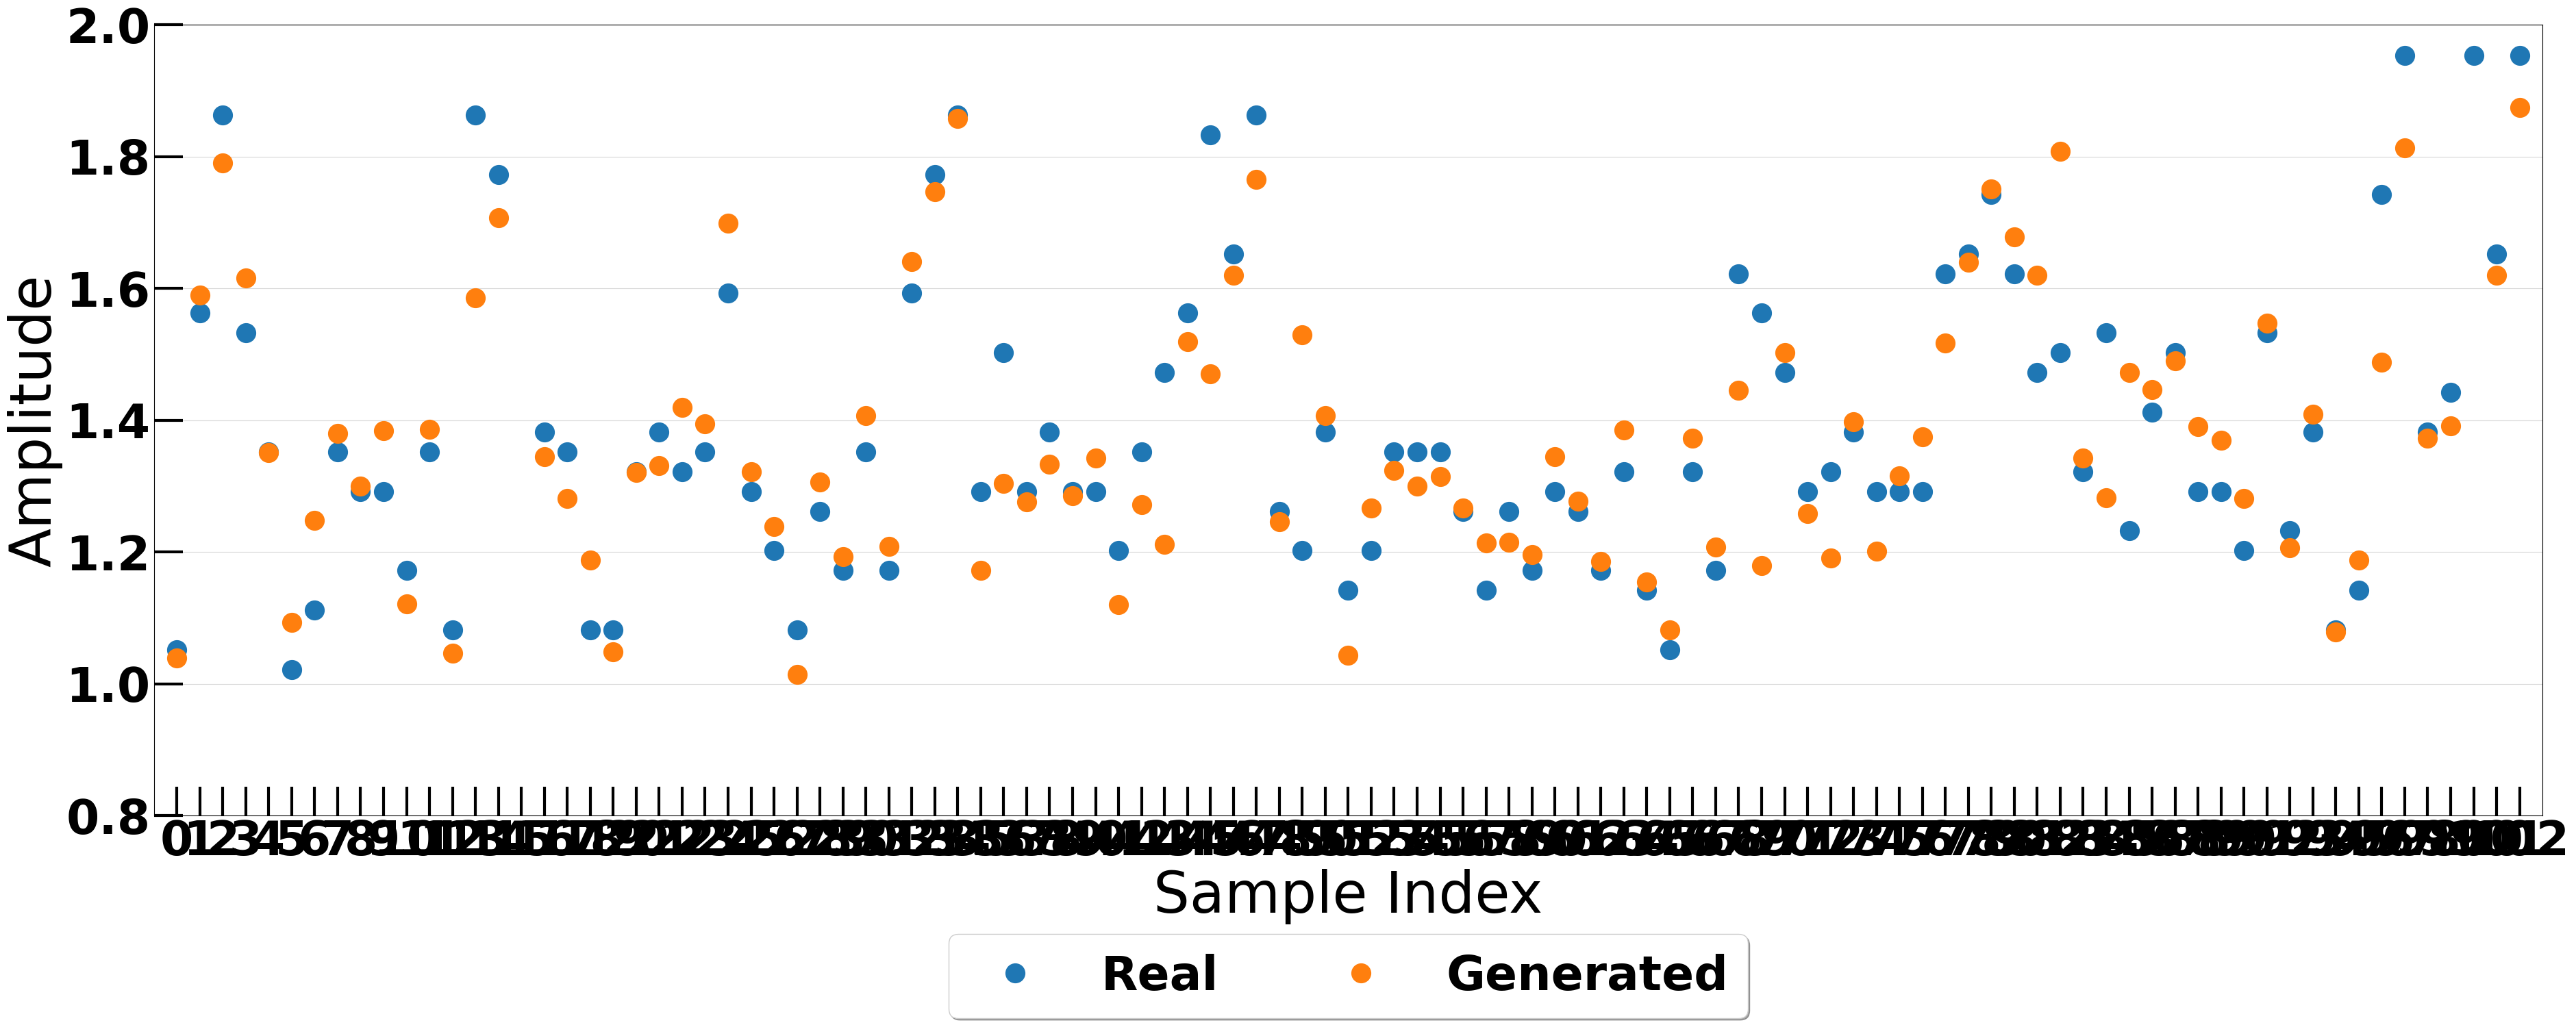

In [130]:
real_signal = TS_5[0]
fake_signal = TS_5_Gen_Signals[0]

time_Signal = np.arange(real_signal.shape[0])
plt.plot(time_Signal, real_signal, 'o', label="Real", markersize=20)
time_Signal = np.arange(fake_signal.shape[0])
plt.plot(time_Signal, fake_signal, 'o',  label="Generated", markersize=20)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(real_signal)])
plt.ylim(.8,2)
plt.xticks(np.arange(len(real_signal)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

In [131]:
print("Average Similarity for Real (TS_5): ", np.mean(Real_Vs_Real))
print("Average Similarity for Generating (TS_5): ", np.mean(Real_Vs_Gen))

Average Similarity for Real (TS_5):  0.19157201182564862
Average Similarity for Generating (TS_5):  1.1346991451191235
